<h1 style="text-align: center;">Physical AI의 Vision-LLM 융합 시청각 멀티모달 시스템</h1>

<br><br>

<div style="text-align: right; color: gray; font-style: italic;">
김규래&emsp;<br>
kkr.kyurae.kim@gmail.com&emsp;
</div><br>

---
---

## 3. 딥러닝 기초 및 GPU 가속

딥러닝(Deep Learning, DL)이란?
"사람의 뇌 신경망을 본떠 만든 인공신경망을 사용해 복잡한 데이터를 학습하는 기술"

인공신경망 (Artificial Neural Network, ANN):
* 인간의 뇌 신경세포(뉴런) 구조를 본떠 만든 학습 모델
* 입력층 (Input Layer), 은닉층 (Hidden Layer), 출력층 (Output Layer)
* 퍼셉트론 (Perceptron)이라는 인공 뉴런을 최소 단위로 사용

---

### A. 퍼셉트론의 구현

#### $1)$ 퍼셉트론의 구조와 개념

퍼셉트론(Perceptron)은 복수의 입력을 받아 각각의 가중치를 곱하고, 여기에 편향을 더해 최종 출력을 만드는 과정이자 인경신공망의 최소 단위입니다. 이번 구현에서는 가장 직관적이고 이해하기 형태인 2개의 입력을 사용하는 퍼셉트론을 살펴봅시다.
* 입력 (input): 모델이 받아들이는 외부의 데이터
* 가중치 (weight): 각 입력이 결과에 미치는 중요도나 영향력을 조절하는 계수
* 가중합: 입력에 각각의 가중치를 곱한 값의 총합
* 편향 (bias): 모델이 얼마나 쉽게 활성화될지(1을 출력할지) 기준을 조절하는 상수

$$
\text{입력: (} x_1 \text{, } x_2 \text{), \hspace{8pt} 가중치: (} w_1 \text{, } w_2 \text{), \hspace{8pt} 가중치: (} b \text{), \hspace{8pt} 출력: (} y \text{)}
$$

#### $2)$ 퍼셉트론의 연산 과정

1. 입력을 받아 입력의 가중합을 구합니다.
$$
w_1x_1 + w_2x_2
$$
2. 구한 가중합에 편향을 더하여 결과 $z$를 계산합니다.
$$
z \hspace{4pt} = \hspace{4pt} w_1x_1 + w_2x_2 + b
$$
3. 최종 산출된 $z$ 값을 사용하여 최종 출력인 $y$ 값으로 변환하기 위하여 활성화 함수 (Activation Function)을 적용합니다 ($y = f(z)$). 다양한 종류의 활성화 함수들이 있지만, 가장 기본적인 계단 함수 (Step Function)을 사용합시다.
$$
y \hspace{5pt} = \hspace{5pt}
\begin{cases}
0 \text{, \hspace{8pt}} z \ge 0\\
1 \text{, \hspace{8pt}} z < 0
\end{cases}
$$

#### $3)$ 퍼셉트론을 활용한 논리회로 구현

수식으로 살펴본 퍼셉트론의 구조와 연산 과정을 바탕으로, Python의 강력한 연산 라이브러리인 `NumPy`를 이용해 실제 코드로 구현합니다.

앞서 정의한 2개의 입력과 편향을 활용하여 논리 회로 중 가장 기초적인 AND 게이트를 퍼셉트론으로 구현하여 결과를 확인해봅시다.

우선 `NumPy` import가 필수입니다.

In [16]:
import numpy as np

논리회로 구현에 사용할 활성화 함수인 step function도 정의합시다.

In [17]:
def step_function(z_):
    if z_ >= 0:
        return 1
    return 0

In [18]:
print(step_function(-1.8))
print(step_function(-100000))
print(step_function(0.0))
print(step_function(2.1))
print(step_function(9999))

0
0
1
1
1


퍼셉트론을 활용한 AND 게이트 구현:

In [19]:
def AND_(x1, x2):
    w1, w2 = 0.5, 0.5  # 가중치 (weight)
    b = -0.7           # 편향 (bias)

    # 가중합과 편향 연산
    z = w1 * x1 + w2 * x2 + b

    # 활성화 함수 적용 (step function)
    y = step_function(z)

    # 최종 출력 반환
    return y

# AND 게이트 예시 실행 결과 확인
print(f"AND(0,0) :  {AND_(0, 0)}")  # 출력: 0
print(f"AND(1,0) :  {AND_(1, 0)}")  # 출력: 0
print(f"AND(0,1) :  {AND_(0, 1)}")  # 출력: 0
print(f"AND(1,1) :  {AND_(1, 1)}")  # 출력: 1

AND(0,0) :  0
AND(1,0) :  0
AND(0,1) :  0
AND(1,1) :  1


동일한 코드를 `NumPy`의 함수를 활용해 다시 구현해봅시다.

In [20]:
def AND(x1, x2):
    x = np.array([x1, x2])    # 입력(input)을 NumPy 배열로 정의
    w = np.array([0.5, 0.5])  # 가중치(weight)를 NumPy 배열로 정의
    b = -0.7                  # 편향(bias)

    # 가중합과 편향 연산
    z = np.sum(x * w) + b

    # 활성화 함수 적용 (step function)
    y = step_function(z)

    # 최종 출력 반환
    return y

# AND 게이트 예시 실행 결과 확인
print(f"AND(0,0) :  {AND(0, 0)}")  # 출력: 0
print(f"AND(1,0) :  {AND(1, 0)}")  # 출력: 0
print(f"AND(0,1) :  {AND(0, 1)}")  # 출력: 0
print(f"AND(1,1) :  {AND(1, 1)}")  # 출력: 1

AND(0,0) :  0
AND(1,0) :  0
AND(0,1) :  0
AND(1,1) :  1


이제 위와 같은 방식으로 OR, NAND, NOR, XOR을 순서대로 퍼셉트론을 활용하여 구현해봅시다.

In [21]:
# TODO: OR 게이트 구현

def OR(x1, x2):
    pass


print(f"OR(0,0) :  {OR(0, 0)}")  # 출력: 0
print(f"OR(1,0) :  {OR(1, 0)}")  # 출력: 1
print(f"OR(0,1) :  {OR(0, 1)}")  # 출력: 1
print(f"OR(1,1) :  {OR(1, 1)}")  # 출력: 1

OR(0,0) :  None
OR(1,0) :  None
OR(0,1) :  None
OR(1,1) :  None


In [22]:
# TODO: NAND 게이트 구현

def NAND(x1, x2):
    pass


print(f"NAND(0,0) :  {NAND(0, 0)}")  # 출력: 1
print(f"NAND(1,0) :  {NAND(1, 0)}")  # 출력: 1
print(f"NAND(0,1) :  {NAND(0, 1)}")  # 출력: 1
print(f"NAND(1,1) :  {NAND(1, 1)}")  # 출력: 0

NAND(0,0) :  None
NAND(1,0) :  None
NAND(0,1) :  None
NAND(1,1) :  None


In [23]:
# TODO: NOR 게이트 구현

def NOR(x1, x2):
    pass


print(f"NOR(0,0) :  {NOR(0, 0)}")  # 출력: 1
print(f"NOR(1,0) :  {NOR(1, 0)}")  # 출력: 0
print(f"NOR(0,1) :  {NOR(0, 1)}")  # 출력: 0
print(f"NOR(1,1) :  {NOR(1, 1)}")  # 출력: 0

NOR(0,0) :  None
NOR(1,0) :  None
NOR(0,1) :  None
NOR(1,1) :  None


In [24]:
# TODO: XOR 게이트 구현

def XOR(x1, x2):
    pass

print(f"XOR(0,0) :  {XOR(0, 0)}")  # 출력: 0
print(f"XOR(1,0) :  {XOR(1, 0)}")  # 출력: 1
print(f"XOR(0,1) :  {XOR(0, 1)}")  # 출력: 1
print(f"XOR(1,1) :  {XOR(1, 1)}")  # 출력: 0

XOR(0,0) :  None
XOR(1,0) :  None
XOR(0,1) :  None
XOR(1,1) :  None


논리회로 결과 비교:

In [25]:
def print_gate_results():
    gates = ["AND", "OR", "NAND", "NOR", "XOR"]
    inputs = [(0, 0), (1, 0), (0, 1), (1, 1)]

    header = "".join(f"{name:>{len(name)+2}s}" for name in gates)
    print(f"x1 x2 |{header}")
    print("-" * (7 + sum(len(name) + 2 for name in gates)))

    for x1, x2 in inputs:
        outputs = (AND(x1,x2), OR(x1,x2), NAND(x1,x2), NOR(x1,x2), XOR(x1,x2))

        row = "".join(f"{str(v):>{len(name)+2}s}"
                      if v is not None
                      else f"{'-':>{len(name)+2}s}"
                      for v, name in zip(outputs, gates))

        print(f"{x1:2d} {x2:2d} |{row}")

print_gate_results()

x1 x2 |  AND  OR  NAND  NOR  XOR
--------------------------------
 0  0 |    0   -     -    -    -
 1  0 |    0   -     -    -    -
 0  1 |    0   -     -    -    -
 1  1 |    1   -     -    -    -


---

### B. 다층 퍼셉트론의 구현

#### 단층 vs. 다층 인공신경망 구조

단층 퍼셉트론 (Single-Layer Perceptron, SLP)
* “입력층 – 출력층”만 존재
* 선형 분리 문제만 해결 가능

다층 퍼셉트론 (Multi-Layer Perceptron, MLP)
* “입력층 – 은닉층 – 출력층” 존재 (하나 이상의 은닉층)
* 비선형 분리 문제 해결 가능

슬라이드에서 확인했듯이, XOR 논리회로는 선형적으로 분리할 수 없는 비선형 문제에 해당합니다.

따라서 이를 해결하기 위해서는 비선형 분리가 가능한 다층 퍼셉트론(MLP) 접근법이 필요하며,
이를 위해 앞서 실습한 단층 구조에 '은닉층(Hidden Layer)'을 추가해야 합니다.

In [26]:
def XOR_(x1, x2):
    # ------------- 입력층 -------------
    x = np.array([x1, x2])

    # ------------- 은닉층 -------------
    w1 = np.array([-0.5, -0.5])
    b1 = 0.7
    z1 = np.sum(x * w1) + b1
    y1 = step_function(z1)

    w2 = np.array([0.5, 0.5])
    b2 = -0.2
    z2 = np.sum(x * w2) + b2
    y2 = step_function(z2)

    # ---------- 은닉층 결과 ------------
    hidden_result = np.array([y1, y2])

    # ---------- 출력층 입력 ------------
    x_output_layer = hidden_result

    # ------------- 출력층 -------------
    w3 = np.array([0.5, 0.5])
    b3 = -0.7
    z3 = np.sum(x_output_layer * w3) + b3
    y = step_function(z3)

    return y

print(f"XOR(0,0) :  {XOR_(0, 0)}")  # 출력: 0
print(f"XOR(1,0) :  {XOR_(1, 0)}")  # 출력: 1
print(f"XOR(0,1) :  {XOR_(0, 1)}")  # 출력: 1
print(f"XOR(1,1) :  {XOR_(1, 1)}")  # 출력: 0

XOR(0,0) :  0
XOR(1,0) :  1
XOR(0,1) :  1
XOR(1,1) :  0


위 코드에서 볼 수 있듯이, XOR 논리회로는 "`AND(NAND(x1,x2), OR(x1,x2))`"입니다.

그러므로, 이전에 정의한 `AND()`, `NAND()`, `OR()` 함수를 사용하여 위의 `XOR()` 함수를 간소화할 수 있습니다.

In [27]:
# XOR(x1,x2) = AND(NAND(x1,x2), OR(x1,x2))
def XOR(x1, x2):
    s1 = NAND(x1, x2)  # 은닉층 노드 1
    s2 = OR(x1, x2)    # 은닉층 노드 2
    y = AND(s1, s2)    # 출력층

    return y

print(f"XOR(0,0) :  {XOR(0, 0)}")  # 출력: 0
print(f"XOR(1,0) :  {XOR(1, 0)}")  # 출력: 1
print(f"XOR(0,1) :  {XOR(0, 1)}")  # 출력: 1
print(f"XOR(1,1) :  {XOR(1, 1)}")  # 출력: 0

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

논리회로 결과 비교:

In [ ]:
print_gate_results()

x1 x2 |  AND  OR  NAND  NOR  XOR
--------------------------------


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

앞서 살펴본 바와 같이, 단층 퍼셉트론을 통해 AND, OR, NAND, NOR 논리 게이트를 성공적으로 구현할 수 있었습니다. 하지만 단층 구조로는 해결할 수 없는 비선형 분류 문제인 XOR 게이트의 경우, 은닉층을 추가한 다층 퍼셉트론 구조를 통해 해결할 수 있음을 확인했습니다.

---

### C. 활성화 함수

활성화 함수 (Activation Function) 이란?
* 다음 뉴런으로 얼마나 신호를 전달할지 결정하는 함수
* 입력 신호를 출력 신호로 변환
* 다양한 종류의 함수 존재 (Step Function, Sigmoid, ReLU 등)

#### $1)$ Step Function

$$
f(x) \hspace{5pt} = \hspace{5pt}
\begin{cases}
1 \text{, \hspace{8pt}} x \ge 0\\
0 \text{, \hspace{8pt}} x < 0
\end{cases}
$$

우선, 앞선 실습에서 정의한 계단 함수부터 살펴보도록 하겠습니다.

In [28]:
def step_function(z_):
    if z_ >= 0:
        return 1
    return 0

In [29]:
print(step_function(-1.8))
print(step_function(-100000))
print(step_function(0.0))
print(step_function(2.1))
print(step_function(9999))

0
0
1
1
1


이 같은 경우, 오직 하나의 값을 입력하여 하나의 값을 출력하는 구조입니다. 하지만, 만약 하나의 층(Layer)에 100개의 퍼셉트론이 존재한다면 활성화 함수를 매번 100번 호출해야 하는 비효율성이 발생합니다.
더 효율적인 연산을 위해 `NumPy` 라이브러리를 활용하여 하나의 층에 포함된 모든 퍼셉트론의 출력값을 하나의 배열로 묶어, 활성화 함수를 단 한 번에 일괄 적용할 수 있습니다.

In [30]:
def step(x):
    return np.array(x > 0, dtype=int)

In [31]:
print(step(np.array([-1.8, -100000, 0.0, 2.1, 9999])))

[0 0 0 1 1]


#### $2)$ Sigmoid

$$
\sigma(x) \hspace{2pt} = \hspace{2pt} \frac{1}{1+e^{-x}}
$$

이번엔 Sigmoid 함수를 동일한 방식으로 정의해봅시다.

In [32]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#### $3)$ ReLU

$$
\mathrm{ReLU}(x) \hspace{2pt} = \hspace{2pt} \max(0,x)
$$

마찬가지로 ReLU 함수도 정의할 수 있습니다.

In [33]:
def relu(x):
    return np.maximum(0, x)

#### 활성화 함수 시각화

이제 정의한 세 활성화 함수를 그래프로 확인해볼까요?

In [34]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# 입력값 범위
x = np.linspace(-5, 5, 100)

# 활성화 함수 적용 후 출력값
y_step = step(x)
y_sigmoid = sigmoid(x)
y_relu = relu(x)

plt.figure(figsize=(16,6))
plt.subplot(1,3,1), plt.plot(x, y_step), plt.title("Step Function"), plt.ylim(-0.1, 1.1), plt.grid()
plt.subplot(1,3,2), plt.plot(x, y_sigmoid), plt.title("Sigmoid Function"), plt.ylim(-0.1, 1.1), plt.grid()
plt.subplot(1,3,3), plt.plot(x, y_relu), plt.title("ReLU Function"), plt.ylim(-0.5, 5), plt.grid();

---

### D. 인공신경망 학습

학습 (Learning):
* 데이터와 정답을 비교해 가중치와 편향을 반복적으로 수정
* 오차를 최소화하는 방향으로 최적화
* 손실 함수(Loss Function)를 기준으로 학습 성능 평가
* 학습률(Learning Rate)을 조절하여 가중치 업데이트 정도 (학습 안정성) 제어

에포크 (Epoch):
* 모델을 한 번 학습하는 과정 (cycle/iteration)
* 에포크를 너무 적게 설정한 경우
  * 학습이 충분히 이루어지지 않음
  * 학습 데이터를 충분히 학습하지 못해 낮은 정확도를 보이는 과소적합(Underfitting) 발생 가능
* 에포크를 너무 많이 설정한 경우
  * 학습 데이터에 과도하게 맞춰짐
  * 학습된 데이터에만 과도하게 최적화되어 처음 보는 데이터에는 대응하지 못하는 과적합(Overfitting) 발생 가능


손실 함수 (Loss Function):
* 모델의 예측값과 실제 정답이 얼마나 다른지 계산
* 손실이 작을수록 모델의 예측이 정답과 가깝다는 의미

손실 함수의 기울기 (Gradient):
* 가중치를 증가/감소시키면 손실이 감소하는지 알 수 있는 지표
* 기울기가 하강하는 방향으로 가중치 수정
* 손실 함수의 기울기는 활성화 함수의 기울기로 계산

$$
\frac{dL}{dw} \hspace{4pt} = \hspace{4pt} \frac{dL}{dy} \hspace{2pt} × \hspace{2pt} \frac{dy}{dz} \hspace{2pt} × \hspace{2pt} \frac{dz}{dw}
$$

학습률 (Learning Rate):
* 한 번의 에포크에서 가중치를 얼마나 많이 변경할 것인지 결정
* 학습률이 너무 작은 경우
  * 학습이 매우 느림
  * 최적 가중치에 도달하는 시간이 오래 걸림
* 학습률이 너무 큰 경우
  * 적절 가중치 값을 지나칠 수 있음
  * 학습이 불안정해질 수 있음

순전파 (Forward Propagation):
* 데이터를 입력하여 다음 층으로 전달하는 과정
* 정답 예측

역전파 (Backpropagation):
* 손실 함수의 기울기를 계산하여 가중치 수정
* 손실(오차)를 거꾸로 층을 거슬러 올라가며 기울기 계산과 가중치 수정 수행

경사하강법 (Gradient Descent):
* 가중치 수정 계산법
* 손실 함수의 기울기를 사용하여 손실(오차)를 가장 낮추는 최적의 가중치를 찾는 과정

$$
w_{new} \hspace{4pt} = \hspace{4pt} w_{old} \hspace{2pt} - \hspace{2pt} \eta \frac{dL}{dw} \text{, \hspace{12pt}} \eta \text{ : 학습률}
$$

#### $1)$ 논리회로 단층 인공신경망 학습

앞서 논리회로 퍼셉트론을 구현할 때는 가중치와 편향을 직접 설정했으나, 이번에는 데이터를 바탕으로 이 값들을 스스로 학습하는 방법과 과정을 살펴보겠습니다.

우선 각 논리회로의 정답을 준비합니다.

In [37]:
targets = {
    "AND": np.array([
        [0],
        [0],
        [0],
        [1],
    ], dtype=float),

    "OR": np.array([
        [0],
        [1],
        [1],
        [1],
    ], dtype=float),

    "NAND": np.array([
        [1],
        [1],
        [1],
        [0],
    ], dtype=float),

    "NOR": np.array([
        [1],
        [0],
        [0],
        [0],
    ], dtype=float),

    "XOR": np.array([
        [0],
        [1],
        [1],
        [0],
    ], dtype=float),
}

그 다음, 인공신경망에 입력될 학습 데이터를 준비합니다.

In [38]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
], dtype=float)

논리회로는 이진 분류 (Binary Classification) 문제로 볼 수 있어, 일반적으로 활성화 함수는 sigmoid와 손실 함수는 Binary Cross-Entropy를 사용합니다.

Sigmoid 함수는 미리 정의해 두었기에 손실 함수만 새로 정의합시다.

In [39]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8

    loss = -np.mean(
        y_true * np.log(y_pred + eps)
        + (1 - y_true) * np.log(1 - y_pred + eps)
    )

    return loss

이제 활성화 함수 `sigmoid()`와 손실 함수 `binary_cross_entropy()`를 사용하여 단층 구조의 신경망을 학습시키는 함수를 정의하고, AND 게이트를 학습해봅시다.

In [40]:
def train_single_neuron(X, y, learning_rate=0.1, epochs=10000):
    # 입력 데이터 배열 크기
    sample_count, input_count = X.shape

    # 입력 데이터 배열 크기에 맞춰 가중치/편향을 초기화
    w = np.zeros((input_count, 1))
    b = np.zeros((1,))

    loss_history = []

    for epoch in range(epochs):
        # 1. 순전파
        z = X @ w + b
        y_pred = sigmoid(z)

        # 2. 손실 계산
        loss = binary_cross_entropy(y, y_pred)
        loss_history.append(loss)

        # 3. 기울기 계산
        error = y_pred - y
        w_gradient = X.T @ error / sample_count
        b_gradient = np.mean(error, axis=0)

        # 4. Weight와 Bias 업데이트
        w -= learning_rate * w_gradient
        b -= learning_rate * b_gradient

    return w, b, loss_history

In [41]:
and_weight, and_bias, and_loss = train_single_neuron(X, targets["AND"], learning_rate=0.1, epochs=10000)

and_probability = sigmoid(X @ and_weight + and_bias)
and_prediction = (and_probability >= 0.5).astype(int)

print("학습된 Weight:")
print(and_weight)
print("학습된 Bias:")
print(and_bias)
print("예측 확률:")
print(and_probability)
print("최종 예측:")
print(and_prediction)

학습된 Weight:
[[7.41095155]
 [7.41095155]]
학습된 Bias:
[-11.2890414]
예측 확률:
[[1.25091034e-05]
 [2.02708979e-02]
 [2.02708979e-02]
 [9.71608460e-01]]
최종 예측:
[[0]
 [0]
 [0]
 [1]]


In [42]:
training_results = {}

for gate_name, target in targets.items():
    weight, bias, loss_history = train_single_neuron(X, target, learning_rate=0.1, epochs=10000)

    probability = sigmoid(X @ weight + bias)
    prediction = (probability >= 0.5).astype(int)

    training_results[gate_name] = {
        "weight": weight,
        "bias": bias,
        "probability": probability,
        "prediction": prediction,
        "loss_history": loss_history,
    }

    print("=" * 50)
    print(f"{gate_name} 게이트")
    print("Weight:")
    print(weight.flatten())
    print("Bias:")
    print(bias)
    print("Probability:")
    print(probability.flatten())
    print("Prediction:")
    print(prediction.flatten())

AND 게이트
Weight:
[7.41095155 7.41095155]
Bias:
[-11.2890414]
Probability:
[1.25091034e-05 2.02708979e-02 2.02708979e-02 9.71608460e-01]
Prediction:
[0 0 0 1]
OR 게이트
Weight:
[8.66020366 8.66020366]
Bias:
[-3.86493825]
Probability:
[0.02053374 0.99179901 0.99179901 0.99999857]
Prediction:
[0 1 1 1]
NAND 게이트
Weight:
[-7.41095155 -7.41095155]
Bias:
[11.2890414]
Probability:
[0.99998749 0.9797291  0.9797291  0.02839154]
Prediction:
[1 1 1 0]
NOR 게이트
Weight:
[-8.66020366 -8.66020366]
Bias:
[3.86493825]
Probability:
[9.79466257e-01 8.20099159e-03 8.20099159e-03 1.43338684e-06]
Prediction:
[1 0 0 0]
XOR 게이트
Weight:
[0. 0.]
Bias:
[0.]
Probability:
[0.5 0.5 0.5 0.5]
Prediction:
[1 1 1 1]


학습 결과는 아래와 같아야 합니다.
* AND
  * Weight: 양수, 양수
  * Bias: 절댓값이 큰 음수
  * Prediction: [0, 0, 0, 1]
* OR
  * Weight: 양수, 양수
  * Bias: AND보다 절댓값이 작은 음수
  * Prediction: [0, 1, 1, 1]
* NAND
  * Weight: 음수, 음수
  * Bias: 큰 양수
  * Prediction: [1, 1, 1, 0]
* NOR
  * Weight: 음수, 음수
  * Bias: NAND보다 작은 양수
  * Prediction: [1, 0, 0, 0]
* XOR (단일 뉴런으로 학습되지 않는다)
  * Weight: 0에 가까운 값
  * Bias: 0에 가까운 값
  * Probability: 약 [0.5, 0.5, 0.5, 0.5]

In [43]:
for gate_name, target in targets.items():
    prediction = training_results[gate_name]["prediction"]
    accuracy = np.mean(prediction == target)

    print(f"{gate_name} accuracy: {accuracy:.2f}")

AND accuracy: 1.00
OR accuracy: 1.00
NAND accuracy: 1.00
NOR accuracy: 1.00
XOR accuracy: 0.50


XOR 정확도가 약 50%라는 것은 단일 뉴런이 XOR 규칙을 학습하지 못했다는 의미이다.

이번에는 epoch가 진행됨에 따라 손실이 어떻게 변화하는지 그래프로 시각화해 봅시다.

In [44]:
plt.figure(figsize=(10, 6))

for gate_name in targets:
    loss_history = training_results[gate_name]["loss_history"]
    plt.plot(loss_history, label=gate_name)

plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Single-neuron Training Loss"), plt.grid(), plt.legend();

* AND, OR, NAND, NOR 손실은 학습이 진행되면서 감소한다.
* XOR 손실은 충분히 감소하지 않는다.
* 모델 구조가 문제를 해결할 수 없으면 Epoch를 증가시켜도 해결되지 않는다.
* 데이터가 충분하고 Epoch가 많더라도 모델 구조 자체가 문제에 적합하지 않으면 학습할 수 없다.

#### $2)$ 논리회로 다층 인공신경망 학습

XOR을 학습하기 위해 다음 구조를 사용합니다.

입력층: 2개
은닉층: 4개 뉴런
출력층: 1개 뉴런

파라미터는 다음과 같습니다.

W1: 입력층 → 은닉층 가중치
b1: 은닉층 편향
W2: 은닉층 → 출력층 가중치
b2: 출력층 편향

파라미터 크기:
X:  (4, 2)
W1: (2, 4)
b1: (1, 4)

Y1: (4, 4)

W2: (4, 1)
b2: (1, 1)

출력: (4, 1)

이제 다층 인공신경망 학습 함수를 정의합시다.

In [45]:
def train_multi_neuron(X, y, hidden_size=4, learning_rate=1.0, epochs=20000, seed=42):
    sample_count, input_count = X.shape
    output_size = 1

    rng = np.random.default_rng(seed)

    W1 = rng.normal(loc=0.0, scale=1.0, size=(input_count, hidden_size))
    b1 = np.zeros((1, hidden_size))
    W2 = rng.normal(loc=0.0, scale=1.0, size=(hidden_size, output_size))
    b2 = np.zeros((1, output_size))

    loss_history = []

    for epoch in range(epochs):
        # 1. 순전파: 입력층 → 은닉층
        Z1 = X @ W1 + b1
        Y1 = sigmoid(Z1)

        # 2. 순전파: 은닉층 → 출력층
        Z2 = Y1 @ W2 + b2
        y_pred = sigmoid(Z2)

        # 3. 손실 계산
        loss = binary_cross_entropy(y, y_pred)
        loss_history.append(loss)

        # 4. 출력층 기울기
        dZ2 = (y_pred - y) / sample_count
        dW2 = Y1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # 5. 은닉층 기울기
        dY1 = dZ2 @ W2.T
        dZ1 = dY1 * Y1 * (1 - Y1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # 6. 파라미터 업데이트
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if epoch % 2000 == 0:
            print(f"Epoch {epoch:5d}, " f"Loss: {loss:.6f}")

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2,
    }

    return parameters, loss_history

이제 정의한 함수를 사용하여 학습을 실행합니다.

In [46]:
xor_parameters, xor_loss_history = train_multi_neuron(
    X,
    targets["XOR"],
    hidden_size=4,
    learning_rate=1.0,
    epochs=20000,
    seed=42,
)

Epoch     0, Loss: 0.756798
Epoch  2000, Loss: 0.003915
Epoch  4000, Loss: 0.001472
Epoch  6000, Loss: 0.000882
Epoch  8000, Loss: 0.000624
Epoch 10000, Loss: 0.000481
Epoch 12000, Loss: 0.000390
Epoch 14000, Loss: 0.000328
Epoch 16000, Loss: 0.000283
Epoch 18000, Loss: 0.000248


학습 결과를 확인해볼까요?

In [47]:
W1 = xor_parameters["W1"]
b1 = xor_parameters["b1"]
W2 = xor_parameters["W2"]
b2 = xor_parameters["b2"]

hidden_output = sigmoid(X @ W1 + b1)
xor_probability = sigmoid(hidden_output @ W2 + b2)
xor_prediction = (xor_probability >= 0.5).astype(int)

print("입력:")
print(X.astype(int))
print("예측 확률:")
print(xor_probability)
print("최종 예측:")
print(xor_prediction)

입력:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
예측 확률:
[[1.25406697e-04]
 [9.99735996e-01]
 [9.99819922e-01]
 [3.15292185e-04]]
최종 예측:
[[0]
 [1]
 [1]
 [0]]


학습된 Weight와 Bias도 확인해봅시다.

In [48]:
print("W1:")
print(W1)
print("b1:")
print(b1)
print("W2:")
print(W2)
print("b2:")
print(b2)

W1:
[[ 5.65783191 -6.78064266  6.7867797  -3.98964783]
 [-7.52169895 -7.24629988 -4.58884642 -3.19885443]]
b1:
[[-2.65787343  2.65529546  1.80758692  5.34531148]]
W2:
[[ 12.18483752]
 [-10.92473602]
 [-10.9515956 ]
 [  8.46805598]]
b2:
[[1.40572112]]


마지막으로, XOR 인공신경망의 손실 변화를 그래프로 확인해봅시다.

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(xor_loss_history)
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("XOR Multi-layer Neural Network Training Loss"), plt.grid();

이와 같이 은닉층을 활용한 다층 인공신경망을 학습시켜 비선형적인 분류 문제를 해결할 수 있음을 확인했습니다.

---

### E. Convolutional Neural Network (CNN) 개요

합성곱 신경망 (CNN)이란?
* 이미지처럼 공간적인 구조를 가진 데이터를 처리하기 위해 설계된 신경망
* 이미지를 2차원 또는 3차원 형태로 유지하면서 주변 픽셀 사이의 패턴을 추출
* 커널(Kernel)을 활용한 합성곱(Convolution) 연산을 통해 이미지의 특징을 추출
* 합성곱의 결과로 특징 맵 (Feature Map)을 생성
* 풀링(Pooling)을 통해 중요한 특징은 유지하면서 데이터 크기를 줄여 연산 효율을 높임
* 추출된 특징을 바탕으로 이미지 분류, 객체 탐지, 얼굴 인식 등 다양한 컴퓨터 비전 분야에서 활용됨

특징 맵 (Feature Map):
* 합성곱(Convolution) 연산의 결과로 생성되는 특징 표현
* 입력 이미지의 특정 특징을 강조하여 나타냄
* 하나의 Kernel당 하나의 Feature Map이 생성됨
* 생성된 Feature Map은 다음 층의 입력으로 사용되어 더 복잡한 특징을 학습

특징 맵 (Feature Map)의 값:
* 해당 위치에서 Filter가 찾는 패턴이 얼마나 강하게 나타나는지를 의미
  * 큰 양수  →  Filter 패턴과 유사한 특징이 강하게 존재
  * 0에 가까운 값  →  특징이 거의 없음
  * 큰 음수  →  Filter 패턴과 반대 방향의 특징이 존재
* CNN에서는 합성곱 결과에 ReLU를 적용하는 경우가 많음
  * 음수 값은 0으로 변환, 양수 값은 유지

####  Feature Map 생성

이전 세션에서 다룬 이미지 전처리 과정인 필터링(Filtering)과 마찬가지로, CNN에서도 이미지 위에서 격자 형태의 커널(Kernel)을 움직이며 합성곱을 계산합니다. 그 결과, 이미지의 핵심 특징이 담긴 Feature Map이 생성됩니다.

연산의 첫 과정은 기존 필터링과 동일합니다. 원하는 특징을 추출하기 위해 적절한 크기의 커널을 정의한 뒤, 이미지 위를 이동하며 합성곱을 계산합니다. 그 이후 CNN에서는 활성화 함수인 ReLU를 적용하여, 원치 않는 특성(음수 값)은 0으로 처리하고 유의미한 특성(양수 값)은 그대로 유지합니다.

우선 필수 라이브러리를 import 합니다. `NumPy`와 `matplotlib`는 위 과정에서 이미 import 했으니, 이미지를 불러오기 위한 `OpenCV` 라이브러리를 import 합시다.

In [61]:
import cv2

Feature Map 실습을 위한 이미지를 불러옵니다.

In [51]:
img_path = "src/images/seagull.jpg"

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")

(-0.5, 959.5, 719.5, -0.5)

오늘 추출할 특징은 edge이므로 색상 정보는 불필요합니다. 그러므로 이미지를 흑백으로 변환합시다.

In [52]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap="gray")
plt.axis("off")

(-0.5, 959.5, 719.5, -0.5)

이제, 2차원 이미지에 하나의 CNN 필터를 적용하는 함수를 정의합니다.

필터를 적용하게 되면 입력 이미지의 크기, 커널의 크기, stride와 padding 값에 따라 최종 출력 이미지의 크기가 결정됩니다.

$H: \hspace{4pt}$ 입력 이미지 높이
$W: \hspace{4pt}$ 입력 이미지 너비
$P: \hspace{4pt}$ Padding 픽셀 값
$K: \hspace{4pt}$ 커널 크기
$S: \hspace{4pt}$ Stride 픽셀 값

$$
height \hspace{4pt} = \hspace{4pt}
\lfloor \frac{H+2P-K}{S} \rfloor \hspace{2pt} + \hspace{2pt} 1
$$

$$
width \hspace{4pt} = \hspace{4pt}
\lfloor \frac{W+2P-K}{S} \rfloor \hspace{2pt} + \hspace{2pt} 1
$$

In [53]:
def convolution2d(image, kernel, bias=0.0, stride=1, padding=0):
    """
    2차원 이미지에 하나의 CNN 필터를 적용.

    Parameters
    ----------
    image : np.ndarray
        입력 이미지, shape = (height, width)
    kernel : np.ndarray
        CNN 필터, shape = (kernel_height, kernel_width)
    bias : float
        필터 출력에 더할 편향
    stride : int
        필터가 이동하는 간격
    padding : int
        입력 이미지 가장자리에 추가할 픽셀의 개수

    Returns
    -------
    output : np.ndarray
        편향까지 적용된 convolution 결과
    """

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # 이미지 가장자리에 zero padding 적용
    padded_image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode="constant",
        constant_values=0
    )

    # (H, W: 입력 이미지 높이 및 너비, P: Padding 픽셀 값, S: Stride 픽셀 값)
    # Convolution 출력 이미지 높이 = floor((H + 2P - K) / S) + 1
    output_height = (padded_image.shape[0] - kernel_height) // stride + 1

    # Convolution 출력 이미지 너비 = floor((W + 2P - K) / S) + 1
    output_width = (padded_image.shape[1] - kernel_width) // stride + 1

    # 계산한 크기로 출력 이미지 준비
    output = np.zeros((output_height, output_width), dtype=np.float32)

    # 커널을 움직이며 필터 적용
    for output_y in range(output_height):
        for output_x in range(output_width):
            # 커널을 적용할 이미지 영역의 좌측상단
            start_y = output_y * stride
            start_x = output_x * stride

            # 커널을 적용할 이미지 영역을 crop
            image_region = padded_image[
                start_y:start_y + kernel_height,
                start_x:start_x + kernel_width
            ]

            # 필터를 적용하여 가중합 계산
            weighted_sum = np.sum(image_region * kernel)

            # 편향 적용
            output[output_y, output_x] = weighted_sum + bias

    return output

이제 CNN의 가중치와 편향을 구해야 합니다. 하지만 이번 실습에서는 모델을 직접 학습시키는 대신, 커널을 통해 Edge를 추출한 Feature Map을 생성하고 확인해 보는 것이 목적이므로 가중치와 편향을 직접 설정하겠습니다.

CNN에서의 가중치와 편향이 무엇을 의미할까요?
* CNN의 가중치: 적용할 필터(커널) 각 칸의 값
* CNN의 편향: 약한 특징을 무시하거나 증폭시키기 위한 값

우선 CNN의 가중치를 설정합시다.

이전 세션의 Sobel Filter 과정에서 배운 것처럼, 가로와 세로 방향의 edge를 검출하기 위한 커널을 각각 정의해봅시다.

In [54]:
# x축 방향 edge (세로 선) 검출 필터
dx_edge_filter = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ],
    dtype=np.float32
)

# y축 방향 edge (가로 선) 검출 필터
dy_edge_filter = np.array(
    [
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ],
    dtype=np.float32
)

그 다음, CNN의 편향도 설정해봅시다.

가로/세로 선 검출 시, 너무 약한 특징은 무시하도록 합시다.

In [55]:
# 너무 약한 특징 (0.2 이하)은 무시
dx_bias = -0.2
dy_bias = -0.2

최종적으로, 이미지에 가중치(필터)와 편향을 적용하는 `convolution2d()` 함수와 앞서 정의한 활성화 함수(ReLU)를 적용하는 `relu()` 함수를 사용하여 Feature Map을 생성합니다.

In [56]:
# 딥러닝 모델에서 더 안정적인 계산을 위해 이미지를 실수(float32)로 변환
input_image = img_gray.astype(np.float32) / 255.

# 가중치와 편향을 적용하여 세로 edge를 검출한 Feature Map 생성
vertical_output = convolution2d(
    image=input_image,
    kernel=dx_edge_filter,
    bias=dx_bias,
    stride=1,
    padding=1
)

# 가중치와 편향을 적용하여 가로 edge를 검출한 Feature Map 생성
horizontal_output = convolution2d(
    image=input_image,
    kernel=dy_edge_filter,
    bias=dy_bias,
    stride=1,
    padding=1
)

# 활성화 함수 (ReLU) 적용
vertical_feature_map = relu(vertical_output)
horizontal_feature_map = relu(horizontal_output)

In [57]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,2), plt.imshow(vertical_output, cmap="gray"), plt.title("Vertical: Convolution + Bias")
plt.subplot(2,3,3), plt.imshow(vertical_feature_map, cmap="gray"), plt.title("Vertical Feature Map + ReLU")
plt.subplot(2,3,4), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,5), plt.imshow(horizontal_output, cmap="gray"), plt.title("Horizontal: Convolution + Bias")
plt.subplot(2,3,6), plt.imshow(horizontal_feature_map, cmap="gray"), plt.title("Horizontal Feature Map + ReLU")

for ax in plt.gcf().axes:
    ax.axis("off")

ReLU를 사용하면 필터가 적용된 결과에서 음수 값을 무시하게 됩니다.
가로/세로 edge 필터를 적용한 결과에서 부호(+/-)는 edge의 방향 정보를 담고 있습니다.

현재 적용한 필터를 예로 들어봅시다.

$$
\begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{bmatrix}
$$

이와 같은 경우, 양수 결과 값은 왼쪽이 어둡고 오른쪽이 밝다는 의미입니다. 음수 결과 값은 반대로 왼쪽이 밝고 오른쪽이 어둡다는 정보를 갖고 있습니다.
ReLU 함수를 적용하면 오직 오른쪽이 왼쪽보다 급격히 밝아지는 영역만 검출하게 됩니다. 이런 결과는 손글씨 인식과 같이 정확한 획의 형태를 파악하는 경우에 유용하게 사용됩니다.

반대 방향 edge를 추출한 Feature Map도 시각화해봅시다.

In [58]:
# 딥러닝 모델에서 더 안정적인 계산을 위해 이미지를 실수(float32)로 변환
input_image = img_gray.astype(np.float32) / 255.

# 필터의 방향을 반대로 설정
dx_reverse_filter = -dx_edge_filter
dy_reverse_filter = -dy_edge_filter

# 가중치와 편향을 적용하여 세로 edge를 검출한 Feature Map 생성
vertical_reverse_output = convolution2d(
    image=input_image,
    kernel=dx_reverse_filter,
    bias=dx_bias,
    stride=1,
    padding=1
)

# 가중치와 편향을 적용하여 가로 edge를 검출한 Feature Map 생성
horizontal_reverse_output = convolution2d(
    image=input_image,
    kernel=dy_reverse_filter,
    bias=dy_bias,
    stride=1,
    padding=1
)

# 활성화 함수 (ReLU) 적용
vertical_reverse_feature_map = relu(vertical_reverse_output)
horizontal_reverse_feature_map = relu(horizontal_reverse_output)

In [59]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,2), plt.imshow(vertical_output, cmap="gray"), plt.title("Vertical: Convolution + Bias")
plt.subplot(2,3,3), plt.imshow(vertical_reverse_feature_map, cmap="gray"), plt.title("Vertical Feature Map + ReLU")
plt.subplot(2,3,4), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,5), plt.imshow(horizontal_output, cmap="gray"), plt.title("Horizontal: Convolution + Bias")
plt.subplot(2,3,6), plt.imshow(horizontal_reverse_feature_map, cmap="gray"), plt.title("Horizontal Feature Map + ReLU")

for ax in plt.gcf().axes:
    ax.axis("off")

비교:

In [60]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,2), plt.imshow(vertical_feature_map, cmap="gray"), plt.title("Vertical Feature Map")
plt.subplot(2,3,3), plt.imshow(vertical_reverse_feature_map, cmap="gray"), plt.title("Vertical Feature Map (Reversed)")
plt.subplot(2,3,4), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,5), plt.imshow(horizontal_feature_map, cmap="gray"), plt.title("Horizontal Feature Map")
plt.subplot(2,3,6), plt.imshow(horizontal_reverse_feature_map, cmap="gray"), plt.title("Horizontal Feature Map (Reversed)")

for ax in plt.gcf().axes:
    ax.axis("off")

앞선 실습에서 확인한 방법으로, Smoothing 필터와 Sharpening 필터를 적용하여 Feature Map을 생성해봅시다.

In [ ]:
# TODO: Smoothing/Sharpening 필터 정의
smoothing_filter = np.array(...)
sharpening_filter = np.array(...)

# TODO: Smoothing/Sharpening 필터 정규화 (필터 정의에서 이미 정규화 하였다면 스킵)
smoothing_filter = ...
sharpening_filter = ...

# TODO: Smoothing/Sharpening 편향 정의
smoothing_bias = ...
sharpening_bias = ...

# TODO: convolution2d 함수를 사용하여 가중치와 편향 적용
smoothing_output = ...
sharpening_output = ...

# TODO: 활성화 함수 적용 (필요할 시)
smoothing_feature_map = ...
sharpening_feature_map = ...


# 결과 시각화
plt.figure(figsize=(12,8))

plt.subplot(2,2,1), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,2,2), plt.imshow(smoothing_output, cmap="gray", vmin=0, vmax=1), plt.title("Smoothing: Convolution + Bias")
plt.subplot(2,2,3), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,2,4), plt.imshow(sharpening_output, cmap="gray", vmin=0, vmax=1), plt.title("Sharpening: Convolution + Bias")

for ax in plt.gcf().axes:
    ax.axis("off")

---

### F. CNN 실습 – MNIST 데이터셋

실습에 앞서 필요한 라이브러리를 설치해야 합니다.

그러기 위해서는 먼저 현재 JetPack과 CUDA 버전을 확인합시다.

```bash
dpkg -l | grep nvidia-jetpack
cat /usr/local/cuda/version.json
```

JetPack 6.2.1 + CUDA 12.6 기준,
```text
torch 2.8.0
torchvision 0.23.0
cu126
```
조합을 사용할 수 있습니다.

설치:

```bash
pip install torch==2.8.0 torchvision --index-url https://pypi.jetson-ai-lab.io/jp6/cu126 --no-deps
pip uninstall torchvision
pip install torchvision==0.23.0 --index-url https://pypi.jetson-ai-lab.io/jp6/cu126 --no-deps
pip install "sympy>=1.13.3" --no-deps
```

In [1]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.8.0
Torchvision version: 0.23.0


위 코드가 에러 없이 실행이 되었다면 다음으로 넘어가면 됩니다.

#### $1)$ 필수 라이브러리 import

우선, 필요한 라이브러리를 전부 import 합시다.

In [2]:
import time
import random

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import torch

#### $2)$ 난수 고정

같은 코드를 반복 실행했을 때 최대한 비슷한 결과를 얻기 위해 난수 seed를 고정합니다.
결과가 완전히 동일하지 않을 수 있지만, 실습 결과의 재현성을 높일 수 있습니다.

In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

#### $3)$ MNIST 데이터셋 설치 및 불러오기

손글씨 데이터셋인 MNIST 데이터를 불러옵시다.

최초로 데이터를 불러올 경우, 지정된 경로에 설치합니다.

In [4]:
# 데이터를 불러올 때 이미지 전처리 방식 정의
# PIL 이미지 또는 NumPy 이미지를 PyTorch Tensor로 변환
# 일반적인 8비트 이미지의 픽셀값을 0~1 범위의 실수로 변환
transform = transforms.ToTensor()

# 학습 데이터 불러오기 (최초 다운로드)
train_dataset = datasets.MNIST(
    root="src/datasets",
    train=True,
    transform=transform,
    download=True,
)

# 테스트 데이터 불러오기 (최초 다운로드)
test_dataset = datasets.MNIST(
    root="src/datasets",
    train=False,
    transform=transform,
    download=True,
)

데이터셋을 설치할 `src/datasets` 폴더가 존재하는지 확인해봅시다.

만약 MNIST 데이터가 올바르게 설치되었다면, `datasets` 안에 `MNIST` 폴더가 자동으로 생성되고 그 내부에 데이터가 위치해 있을 것입니다.

아래 코드를 통해 확인해봅시다.

In [5]:
print(
    "Train data:",
    len(train_dataset)
)

print(
    "Test data:",
    len(test_dataset)
)

Train data: 60000
Test data: 10000


정상적으로 설치되었다면 학습 데이터는 60000개, 테스트 데이터는 10000개가 존재할 것입니다.

#### $4)$ MNIST 데이터 확인

설치된 MNIST 데이터를 확인해봅시다.

In [6]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)
print("Minimum:", image.min().item())
print("Maximum:", image.max().item())

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([1, 28, 28])
Label: 5
Minimum: 0.0
Maximum: 1.0


해당 코드의 결과는 다음과 같아야 합니다.

Image type: <class 'torch.Tensor'><br>
Image shape: torch.Size([1, 28, 28])<br>
Label: 5<br>
Minimum: 0.0<br>
Maximum: 1.0

특히, 이미지의 크기가 `1x28x28`인 것을 확인해야 합니다.

#### $5)$ MNIST 데이터 시각화

우선, 위에서 간단한 확인을 위해 선택한 `train_data[0]`을 확인해봅시다.

/home/bang/vision-llm/.venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


(-0.5, 27.5, 27.5, -0.5)

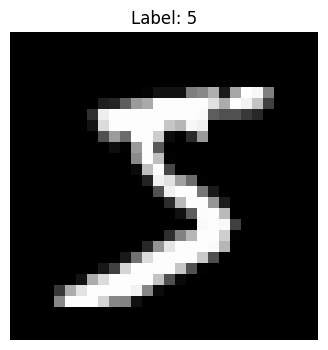

In [7]:
import matplotlib.pyplot as plt
image_2d = image.squeeze(0)

plt.figure(figsize=(4,4))
plt.imshow(image_2d, cmap="gray"), plt.title(f"Label: {label}")
plt.axis("off")

이번에는 `train_data` 총 20개를 시각화해 봅시다.

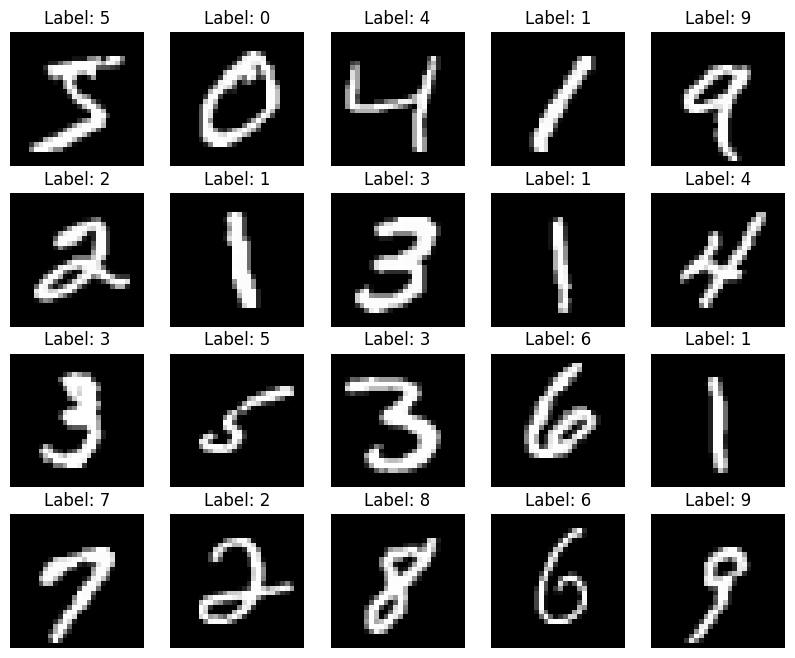

In [8]:
plt.figure(figsize=(10,8))

for index in range(20):
    image, label = train_dataset[index]
    plt.subplot(4,5,index+1), plt.imshow(image.squeeze(0), cmap="gray"), plt.title(f"Label: {label}")
    plt.axis("off")

여기서 알 수 있는 사실은:
* 같은 숫자라도 사람마다 쓰는 방식이 다르다.
* 숫자의 위치가 조금씩 다르다.
* 획의 굵기와 기울기가 다르다.
* 일부 숫자는 다른 숫자와 비슷하게 보일 수 있다.

#### $6)$ DataLoader 생성

DataLoader의 역할:
* Dataset은 이미지 한 장과 Label 하나를 반환 (`image, label = train_dataset[0]`)
* DataLoader는 총 70,000개의 데이터를 지정한 사이즈의 하나의 묶음(Batch)으로 불러와 모델에 전달
* 실제 학습에서는 한 장씩 모델에 입력 값으로 전달하기 보다는, 여러 이미지를 하나의 Batch로 묶어서 입력에 전달한다

DataLoader이 제공하는 기능:
* Batch 생성
* Batch 단위 반복
* 데이터 순서 섞기
* 데이터 로딩 과정 관리

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=0,
)

DataLoader가 묶은 Batch를 확인해봅시다.

In [10]:
images, labels = next(
    iter(train_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

images, labels = next(
    iter(test_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
Images shape: torch.Size([1000, 1, 28, 28])
Labels shape: torch.Size([1000])


#### $7)$ CNN 모델 정의

28x28 크기를 가진 MNIST 이미지를 활용하는 CNN의 전체 구조는 아래와 같습니다.

<div style="text-align: center;">
  [입력]<br>
  1 × 28 × 28<br>
  ↓<br>
  [Conv1]<br>
  8 × 28 × 28<br>
  ↓<br>
  [ReLU]<br>
  8 × 28 × 28<br>
  ↓<br>
  [Max Pooling]<br>
  8 × 14 × 14<br>
  ↓<br>
  [Conv2]<br>
  16 × 14 × 14<br>
  ↓<br>
  [ReLU]<br>
  16 × 14 × 14<br>
  ↓<br>
  [Max Pooling]<br>
  16 × 7 × 7<br>
  ↓<br>
  [Flatten]<br>
  784<br>
  ↓<br>
  [Fully Connected]<br>
  64<br>
  ↓<br>
  [Fully Connected]<br>
  10
</div>

CNN 모델 정의:

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        self.fc1 = nn.Linear(
            16 * 7 * 7,
            64,
        )

        self.fc2 = nn.Linear(
            64,
            10,
        )

    def forward(self, x, return_features=False):
        conv1_output = self.conv1(x)
        relu1_output = F.relu(conv1_output)
        pool1_output = self.pool(relu1_output)
        conv2_output = self.conv2(pool1_output)
        relu2_output = F.relu(conv2_output)
        pool2_output = self.pool(relu2_output)
        flattened = torch.flatten(pool2_output, start_dim=1)
        fc1_output = F.relu(self.fc1(flattened))
        logits = self.fc2(fc1_output)

        if return_features:
            features = {
                "conv1": conv1_output,
                "relu1": relu1_output,
                "pool1": pool1_output,
                "conv2": conv2_output,
                "relu2": relu2_output,
                "pool2": pool2_output,
            }

            return logits, features

        return logits

위에서 정의한 CNN 모델 구조를 시각화해 봅시다. 그러기 위해서는 모델 시각화 도구인 `visualtorch`가 필요합니다.

```bash
pip install Pillow==10.4.0 --no-deps
pip install aggdraw==1.3.19 --no-deps
pip install visualtorch==1.4.1 --no-deps
```

In [12]:
import visualtorch

Import가 오류 없이 되었다면 다음 코드를 통해 시각화해 봅시다.

In [13]:
def visualize_model(model, input_shape):
    model_img = visualtorch.render(
        model,
        input_shape=input_shape,
        style="flow",
        legend=True,
        scale_xy=4,
        min_xy=2,
        max_xy=500,
        )

    return model_img

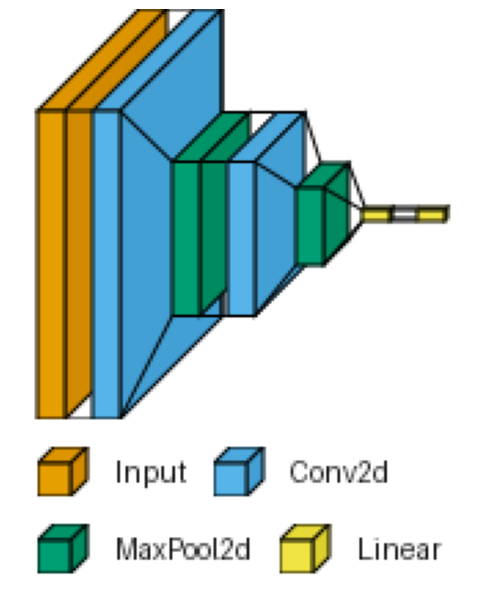

In [14]:
model_struct = visualize_model(SimpleCNN(), (1,1,28,28))

plt.figure(figsize=(6,8))
plt.imshow(model_struct)
plt.axis("off");

#### $8)$ 모델 생성 및 CPU 지정

위에 정의한 CNN 모델을 생성합시다. 이 모델이 학습되기 위해서는 CPU/GPU 사용 여부를 설정해야 합니다.

In [15]:
device = torch.device("cpu")

torch.manual_seed(seed)

model = SimpleCNN()
model = model.to(device)

print("Device:", device)
print(model)

Device: cpu
SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


모델이 학습할 파라미터 수를 확인해봅시다.

In [16]:
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", parameter_count)
print("Trainable parameters:", trainable_parameter_count)

Total parameters: 52138
Trainable parameters: 52138


#### $9)$ 순전파 기능 확인

실제 데이터를 학습하기 전에 임의의 입력(Dummy Input)을 모델에 전달하여 순전파(forward) 기능을 확인합시다.

In [17]:
dummy_input = torch.randn(1, 1, 28, 28)
dummy_output = model(dummy_input)

print("Input shape:", dummy_input.shape)
print("Output shape:", dummy_output.shape)

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])


입력 데이터는 MNIST의 기본 규격인 28×28 크기의 흑백(단일 채널) 이미지이며, 순전파 연산 결과 10개의 클래스(정수 0~9)로 출력됩니다.

이번에는, Batch 하나를 불러와 순전파의 각 단계별 데이터의 크기를 확인해봅시다.

In [18]:
sample_images, sample_labels = next(
    iter(train_loader)
)

sample_images = sample_images.to(device)

with torch.no_grad():
    logits, features = model(
        sample_images,
        return_features=True,
    )

print("Input:", sample_images.shape)

for name, feature in features.items():
    print(f"{name}:", feature.shape)

print("Logits:", logits.shape)

Input: torch.Size([64, 1, 28, 28])
conv1: torch.Size([64, 8, 28, 28])
relu1: torch.Size([64, 8, 28, 28])
pool1: torch.Size([64, 8, 14, 14])
conv2: torch.Size([64, 16, 14, 14])
relu2: torch.Size([64, 16, 14, 14])
pool2: torch.Size([64, 16, 7, 7])
Logits: torch.Size([64, 10])


#### $10)$ Feature Map 확인

CNN 각 층의 Feature Map을 확인하기 위한 함수를 정의합니다.

In [19]:
def show_feature_maps(feature_tensor, title, max_maps=8, cmap="gray"):
    if feature_tensor.ndim != 4:
        raise ValueError("Feature Tensor는 [Batch, Channel, Height, Width] 형태여야 합니다.")

    feature_maps = feature_tensor[0].detach().cpu()

    channel_count = min(feature_maps.shape[0], max_maps)
    column_count = 4
    row_count = int(np.ceil(channel_count / column_count))

    plt.figure(figsize=(12, 3 * row_count))

    for channel_index in range(channel_count):
        plt.subplot(row_count, column_count, channel_index + 1)
        plt.imshow(feature_maps[channel_index], cmap=cmap)
        plt.title(f"Channel {channel_index}")
        plt.axis("off")
        plt.suptitle(title)

이제 입력 이미지 한 장을 선택하여 순전파를 적용해봅시다.

이미지 한 장만 선택하기에 Batch 차원이 없습니다. 그러므로 `unsqueeze(0)`를 사용하여 차원을 추가합니다.

In [20]:
image, label = test_dataset[0]

input_batch = image.unsqueeze(0).to(device)

print("Single image:", image.shape)
print("Batch image:", input_batch.shape)

Single image: torch.Size([1, 28, 28])
Batch image: torch.Size([1, 1, 28, 28])


순전파 실행:

In [21]:
model.eval()

with torch.no_grad():
    logits, features = model(
        input_batch,
        return_features=True,
    )

원본 이미지 출력:

(-0.5, 27.5, 27.5, -0.5)

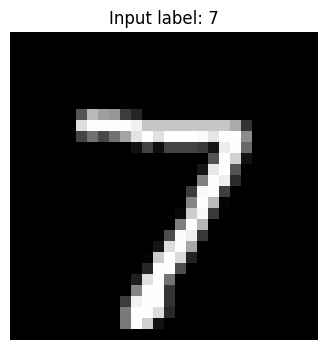

In [22]:
plt.figure(figsize=(4,4))

plt.imshow(image.squeeze(0), cmap="gray"), plt.title(f"Input label: {label}")
plt.axis("off")

첫 번째 Convolution 결과:

Channel 0: Conv min=0.252480, Conv max=1.411136, 
Channel 1: Conv min=-0.453152, Conv max=0.638269, 
Channel 2: Conv min=-1.015003, Conv max=-0.213439, 
Channel 3: Conv min=-0.737451, Conv max=0.117844, 
Channel 4: Conv min=-0.249831, Conv max=0.620810, 
Channel 5: Conv min=-0.404385, Conv max=0.325157, 
Channel 6: Conv min=-0.113948, Conv max=0.632330, 
Channel 7: Conv min=-0.035502, Conv max=0.571724, 


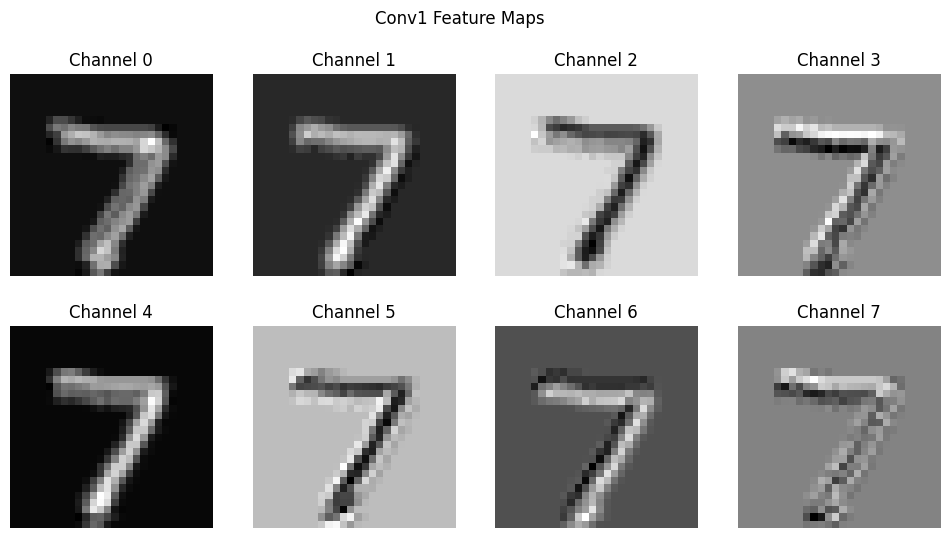

In [23]:
show_feature_maps(
    features["conv1"],
    title="Conv1 Feature Maps",
    max_maps=8,
)
for i in range(8):
    conv = features["conv1"][0, i]

    print(
        f"Channel {i}: "
        f"Conv min={conv.min().item():.6f}, "
        f"Conv max={conv.max().item():.6f}, "
        )

학습 전 모델에서 Feature Map을 출력하면 Filter가 무작위로 초기화되어 있기 때문에 의미 있는 특징이 명확하게 나타나지 않습니다.

학습 후에는 숫자 분류에 유용한 선, 방향, 경계 등에 반응하는 Feature Map이 나타납니다.

이번엔 ReLU까지 적용하여 확인해봅시다.

첫 번째 ReLU 결과:

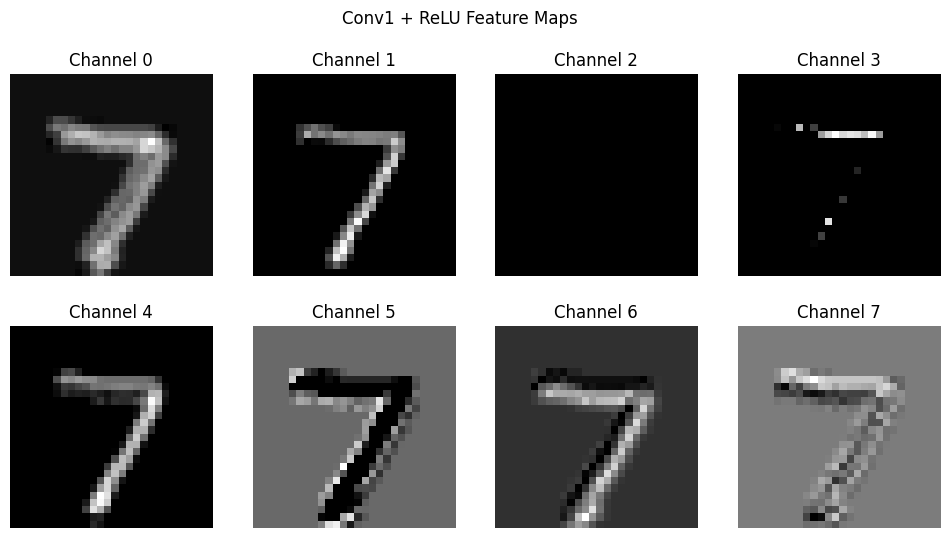

In [24]:
show_feature_maps(
    features["relu1"],
    title="Conv1 + ReLU Feature Maps",
    max_maps=8,
)

ReLU를 적용하면 음수 반응(원치 않는 특성)은 모두 0으로 처리됩니다. 여전히 학습되기 전이기에 원하는 특성을 추출하는 가중치(필터)가 없어 큰 의미를 찾기는 어렵습니다.

다음으로 Pooling을 적용해봅시다.

첫 번째 Pooling 결과:

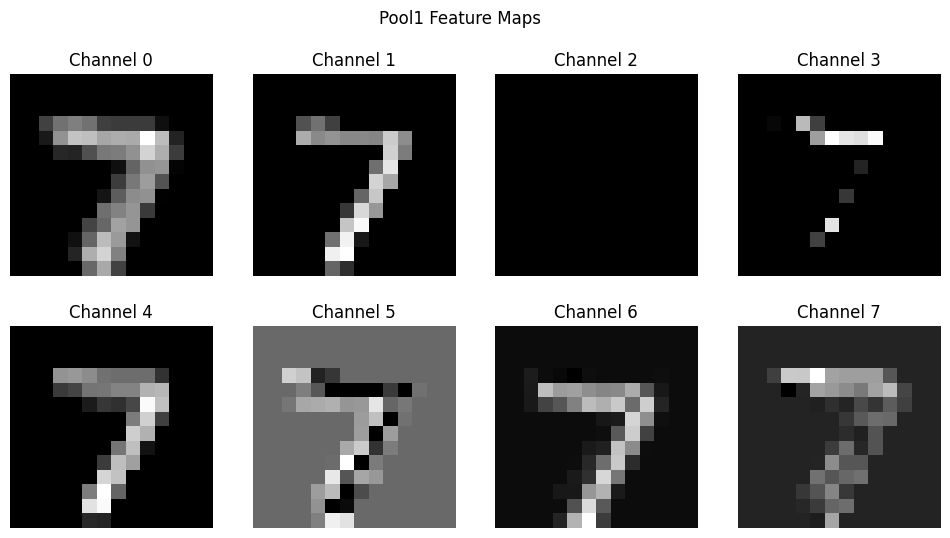

In [25]:
show_feature_maps(
    features["pool1"],
    title="Pool1 Feature Maps",
    max_maps=8,
)

이미지의 크기가 28x28에서 14x14로 줄어든 것을 확인할 수 있습니다.

두 번째 Convolution 결과:

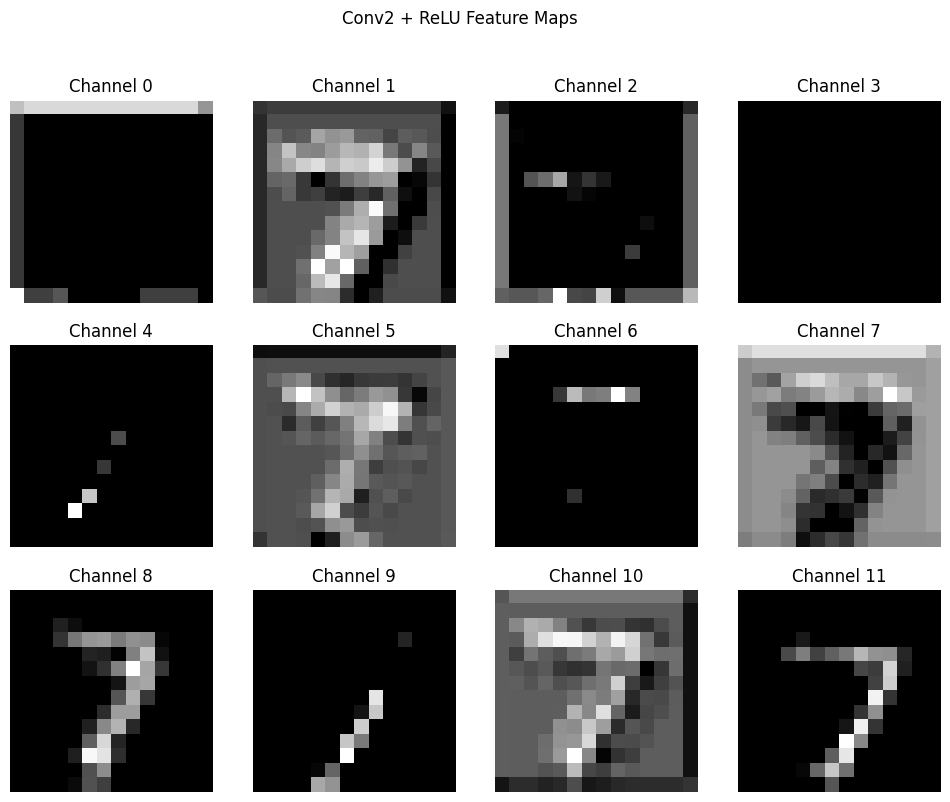

In [26]:
show_feature_maps(
    features["relu2"],
    title="Conv2 + ReLU Feature Maps",
    max_maps=12,
)

두 번째 Layer는 첫 번째 Layer에서 추출한 특징들을 조합합니다.

따라서 단순한 Edge보다 숫자의 획이나 모양 일부에 반응하는 형태가 나타날 수 있습니다.

두 번째 Pooling 결과:

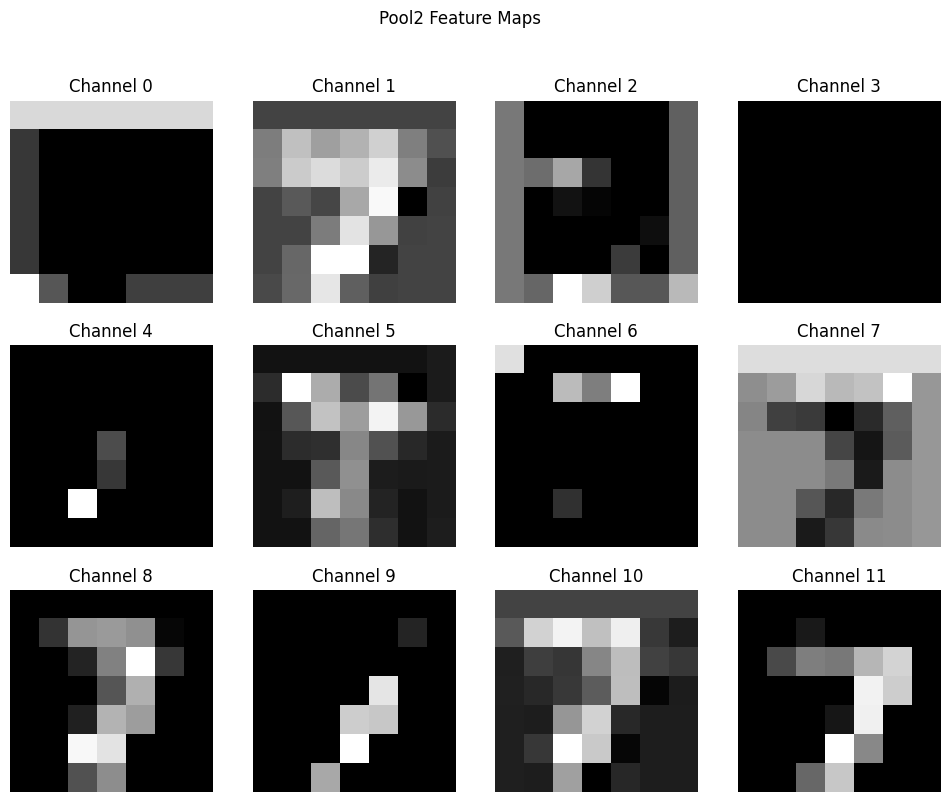

In [27]:
show_feature_maps(
    features["pool2"],
    title="Pool2 Feature Maps",
    max_maps=12,
)

최종 Feature Map 크기는 16×7×7 입니다.

이 특징들이 Flatten과 Fully Connected Layer로 전달됩니다.

#### $11)$ 가중치(필터) 확인

첫 번째 Convolution Layer의 가중치 크기를 확인합시다.

In [28]:
conv1_weights = model.conv1.weight.detach().cpu()
print(conv1_weights.shape)

torch.Size([8, 1, 3, 3])


3x3 필터 8개를 가중치로 가지고 있는 것을 확인할 수 있습니다.

필터들을 시각화해 봅시다.

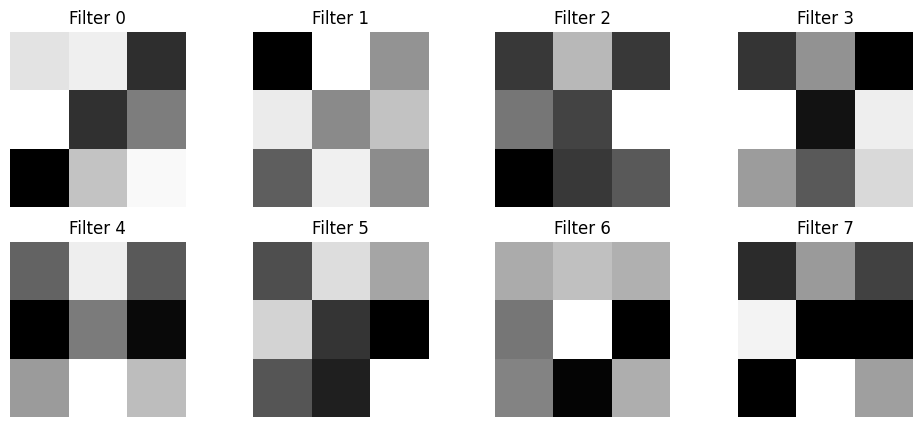

In [29]:
plt.figure(figsize=(12,5))

for filter_index in range(conv1_weights.shape[0]):
    plt.subplot(2, 4, filter_index + 1)
    plt.imshow(conv1_weights[filter_index, 0], cmap="gray")
    plt.title(f"Filter {filter_index}")
    plt.axis("off")

학습 전에는 무작위 Filter가 나타납니다.

학습 후 같은 코드를 다시 실행하면 가중치가 변경된 것을 확인할 수 있습니다.

#### $12)$ 손실 함수와 Optimizer 설정

MNIST는 10개 클래스 중 하나를 선택하는 다중 클래스 분류 문제이다. 해당 실습에서는 정답 분포와 예측 분포의 차이를 측정하여 다중 클래스를 분류하는 손실 함수인 Cross Entropy를 사용합니다.

In [30]:
criterion = nn.CrossEntropyLoss()

CrossEntropyLoss에는 모델의 원시 출력인 Logit을 직접 입력합니다. 그러므로 학습 코드에서 Cross Entropy 앞에 Softmax를 별도로 적용하여 입력하지 않습니다.

Optimizer는 역전파로 계산된 Gradient를 사용하여 CNN의 Filter, Bias, Fully Connected Weight 등을 수정합니다.

In [31]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

#### $13)$ CNN 모델 학습

CNN 모델 학습은 Batch 단위로 진행됩니다.

하나의 Batch 학습 순서는 다음과 같습니다.

1. 이미지와 Label을 CPU로 이동
2. 기존 Gradient 초기화
3. CNN 순전파
4. Loss 계산
5. CNN 역전파
6. Weight 업데이트

해당 과정을 함수로 정의합니다.

In [32]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # 모델을 학습 모드(training mode)로 변경
    model.train()

    # 결과를 누적하기 위한 변수
    total_loss = 0.0
    correct_count = 0
    sample_count = 0

    # 학습 데이터를 DataLoader(train_loader)의 Batch 단위로 불러와 학습 반복
    for images, labels in data_loader:
        # CPU로 이동
        images = images.to(device)
        labels = labels.to(device)

        # Gradient 초기화 (이전 Batch에서 계산한 Gradient를 제거)
        optimizer.zero_grad()

        # 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
        logits = model(images)

        # Loss 계산
        loss = criterion(logits, labels)
        # 역전파를 통한 Gradient 계산
        loss.backward()
        # Gradient를 사용하여 파라미터 수정
        optimizer.step()

        # Batch 한 개의 이미지 개수
        batch_size = images.size(0)

        # 결과 누적
        total_loss += loss.item() * batch_size                 # Loss 누적 (1개 batch의 평균 loss x batch 크기)
        predictions = logits.argmax(dim=1)                     # 가장 높은 점수를 가진 클래스를 선택
        correct_count += (predictions == labels).sum().item()  # 정답을 맞춘 개수 계산
        sample_count += batch_size                             # 전체 샘플 수 누적

    # 평균 Loss 및 Accuracy 계산
    average_loss = total_loss / sample_count
    accuracy = correct_count / sample_count

    return average_loss, accuracy

#### $14)$ CNN 모델 평가

모델 학습이 완료되었다면, 제대로 학습이 되었는지 테스트 데이터로 평가를 해야합니다.

평가(테스트) 과정에서는 가중치를 수정하지 않습니다.

학습된 모델을 평가하는 함수를 정의합시다.

In [33]:
def evaluate(model, data_loader, criterion, device):
    # 모델을 평가 모드(evaluation mode)로 변경
    model.eval()

    # 결과를 누적하기 위한 변수
    total_loss = 0.0
    correct_count = 0
    sample_count = 0

    # Gradient 계산을 비활성화 (파라미터 수정 비활성화)
    with torch.no_grad():
        # 평가 데이터를 DataLoader(test_loader)의 Batch 단위로 불러와 평가 반복
        for images, labels in data_loader:
            # CPU로 이동
            images = images.to(device)
            labels = labels.to(device)

            # 학습된 모델의 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
            logits = model(images)

            # Loss 계산 (역전파는 수행하지 않음)
            loss = criterion(logits, labels)

            # Batch 한 개의 이미지 개수
            batch_size = images.size(0)

            # 결과 누적
            total_loss += loss.item() * batch_size                 # Loss 누적 (1개 batch의 평균 loss x batch 크기)
            predictions = logits.argmax(dim=1)                     # 가장 높은 점수를 가진 클래스를 선택
            correct_count += (predictions == labels).sum().item()  # 정답을 맞춘 개수 계산
            sample_count += batch_size                             # 전체 샘플 수 누적

        # 평균 Loss 및 Accuracy 계산
        average_loss = total_loss / sample_count
        accuracy = correct_count / sample_count

        return average_loss, accuracy

#### $15)$ MNIST 숫자 손글씨 추론

지금까지 MNIST 손글씨 숫자 분류 모델을 추론하기 위한 전체 구성 요소를 단계적으로 구현했습니다.

진행한 과정은 다음과 같습니다.

- MNIST 데이터셋을 설치하고 학습 데이터와 테스트 데이터를 불러오기
- DataLoader를 생성하여 데이터를 batch 단위로 처리할 수 있도록 구성
- CNN 기반 분류 모델을 class 형태로 정의하고 Convolution, Pooling, Fully Connected Layer 설정
- 정의한 CNN 모델을 불러와 생성하고 연산 장치(device)를 CPU로 지정
- 모델 학습에 사용할 손실 함수와 optimizer 설정
- CNN 모델의 학습 과정을 수행하는 `train_one_epoch()` 함수 정의
- 학습된 모델의 성능을 평가하는 `evaluate()` 함수 정의

이번 단계에서는 앞에서 구현한 데이터 처리 과정, CNN 모델, loss 함수, optimizer, 학습 및 평가 함수를 연결하여 모델을 실제로 학습시키고, 테스트 데이터에 대한 성능을 확인한 뒤 새로운 손글씨 숫자를 예측합니다.

Epoch 1/3 | Train loss: 0.3136 | Train accuracy: 90.70% | Test loss: 0.1023 | Test accuracy: 96.88% | Time: 184.53s
Epoch 2/3 | Train loss: 0.0976 | Train accuracy: 97.00% | Test loss: 0.0661 | Test accuracy: 97.92% | Time: 178.29s
Epoch 3/3 | Train loss: 0.0694 | Train accuracy: 97.87% | Test loss: 0.0551 | Test accuracy: 98.27% | Time: 128.40s
Total CPU training time: 491.22s
True label: 7
Predicted label: 7
Confidence: 0.9998775720596313


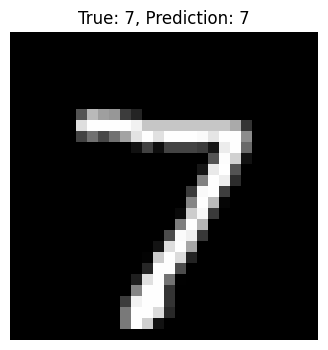

In [34]:
# 총 Epoch 정의 (전체 학습 데이터를 몇 번 반복해서 볼 것인지)
epochs = 3

# 학습 기록 저장 공간 준비
train_loss_history = []
train_accuracy_history = []
test_loss_history = []
test_accuracy_history = []

# 전체 학습 시간 측정 시작
training_start_time = time.perf_counter()

for epoch in range(epochs):
    # Epoch 시작 시간 저장
    epoch_start_time = time.perf_counter()

    # 모델 학습
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    # 모델 평가
    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    # 결과 저장 (학습 & 평가)
    train_loss_history.append(train_loss)
    train_accuracy_history.append(train_accuracy)
    test_loss_history.append(test_loss)
    test_accuracy_history.append(test_accuracy)

    # Epoch 소요 시간 계산
    epoch_time = time.perf_counter() - epoch_start_time

    # 현재 Epoch의 학습/평가 결과 출력
    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: "
        f"{train_accuracy * 100:.2f}% | "
        f"Test loss: {test_loss:.4f} | "
        f"Test accuracy: "
        f"{test_accuracy * 100:.2f}% | "
        f"Time: {epoch_time:.2f}s"
    )

# 전체 학습 시간 계산 및 출력
total_training_time = time.perf_counter() - training_start_time
print(f"Total CPU training time: {total_training_time:.2f}s")

# 학습된 모델로 이미지 하나 테스트
image, true_label = test_dataset[0]          # 테스트할 이미지(image)와 정답(label)
input_batch = image.unsqueeze(0).to(device)  # Batch 차원 추가(unsqueeze)하여 입력 Batch로 저장 (이미지 1장)

# 모델을 평가 모드(evaluation mode)로 변경
model.eval()

# Gradient 계산을 비활성화 (파라미터 수정 비활성화)
with torch.no_grad():
    logits = model(input_batch)                           # 학습된 모델의 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
    probabilities = torch.softmax(logits, dim=1)          # 원시 점수에 softmax 함수 적용 (클래스별 확률 계산)
    predicted_label = probabilities.argmax(dim=1).item()  # 정답 예측

# 결과 출력 (정답, 예측, confidence)
print("True label:", true_label)
print("Predicted label:", predicted_label)
print("Confidence:", probabilities[0, predicted_label].item())

# 결과 이미지 출력
plt.figure(figsize=(4,4))
plt.imshow(image.squeeze(0), cmap="gray")
plt.title(f"True: {true_label}, " f"Prediction: {predicted_label}")
plt.axis("off")
plt.show()

이제 여러 장의 손글씨 숫자를 추론해 확인해봅시다.

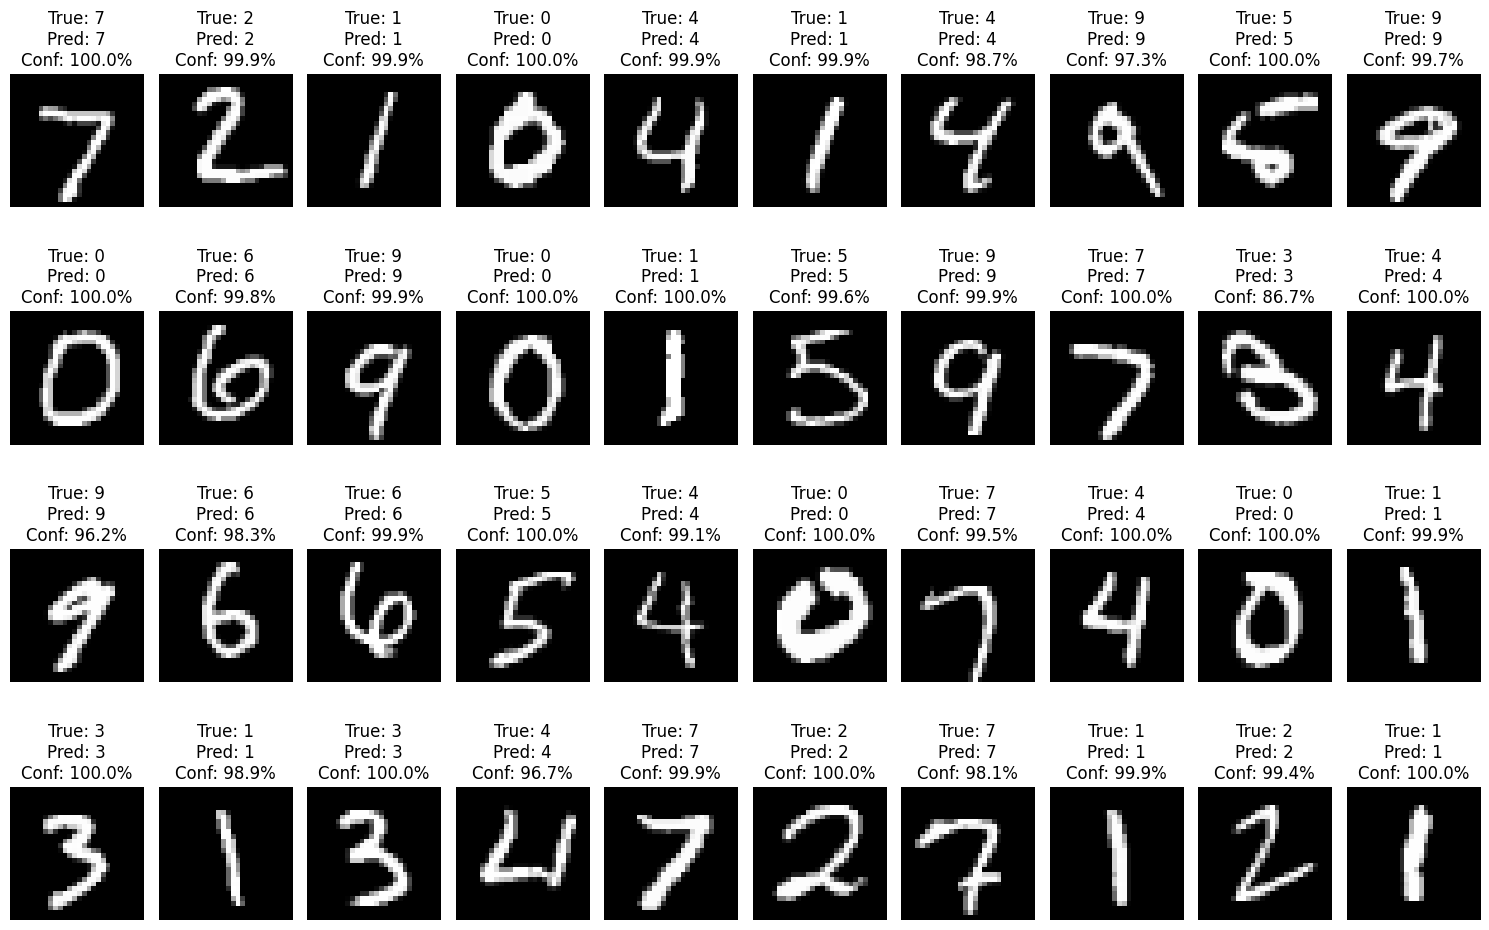

In [35]:
plt.figure(figsize=(15,10))

num_images = 40

model.eval()

with torch.no_grad():
    for i in range(num_images):
        image, true_label = test_dataset[i]
        input_batch = image.unsqueeze(0).to(device)

        logits = model(input_batch)
        probabilities = torch.softmax(logits, dim=1)
        predicted_label = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_label].item()

        plt.subplot(4, 10, i+1)
        plt.imshow(image.squeeze(0), cmap="gray")
        plt.title(
            f"True: {true_label}\n"
            f"Pred: {predicted_label}\n"
            f"Conf: {confidence*100:.1f}%"
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

#### $16)$ 모델 성능 확인

위 과정에서, 학습이 진행됨에 따라 Epoch별 학습 및 평가의 Loss와 Accuracy를 리스트에 저장했습니다.

해당 지표들을 Epoch별 그래프로 시각화하여 확인해봅시다.

우선 Loss 그래프입니다.

/tmp/ipykernel_9271/524397399.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


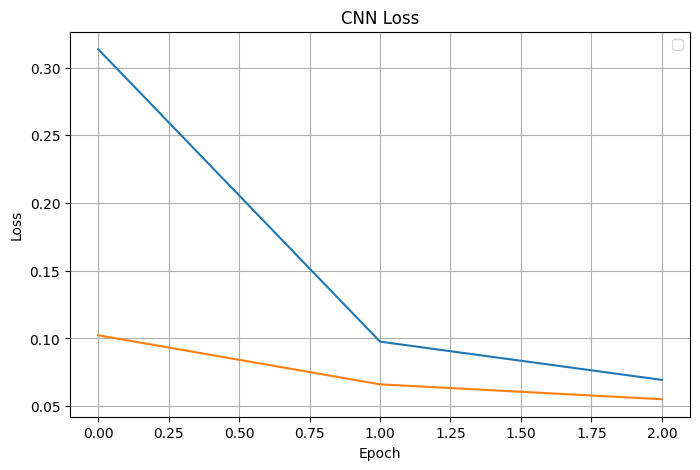

In [38]:
# TODO: plt.plot(x축_데이터, y축_데이터, marker="o", label="데이터_이름")을 사용하여 그래프 생성
plt.figure(figsize=(8,5))

# TODO: train_loss_history 그래프 생성
plt.plot(train_loss_history)
# TODO: test_loss_history 그래프 생성
plt.plot(test_loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.grid()
plt.legend()
plt.show()

다음은 Accuracy 그래프입니다.

/tmp/ipykernel_9271/1555503284.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


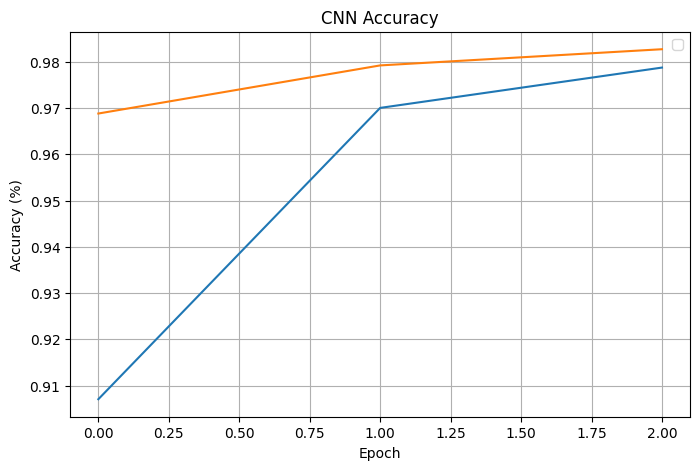

In [39]:
# TODO: plt.plot(x축_데이터, y축_데이터, marker="o", label="데이터_이름")을 사용하여 그래프 생성
plt.figure(figsize=(8,5))

# TODO: train_accuracy_history 그래프 생성 (백분율)
plt.plot(train_accuracy_history)
# TODO: test_accuracy_history 그래프 생성 (백분율)
plt.plot(test_accuracy_history)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Accuracy")
plt.grid()
plt.legend()
plt.show()

#### $17)$ 학습된 모델의 Feature Map 확인

앞선 과정에서 모델 학습이 완료되었으니, 이제 각 층(layer)의 Feature Map을 다시 확인해봅시다. 이미 `show_feature_maps()` 함수를 위에서 정의했으니 활용하면 됩니다.

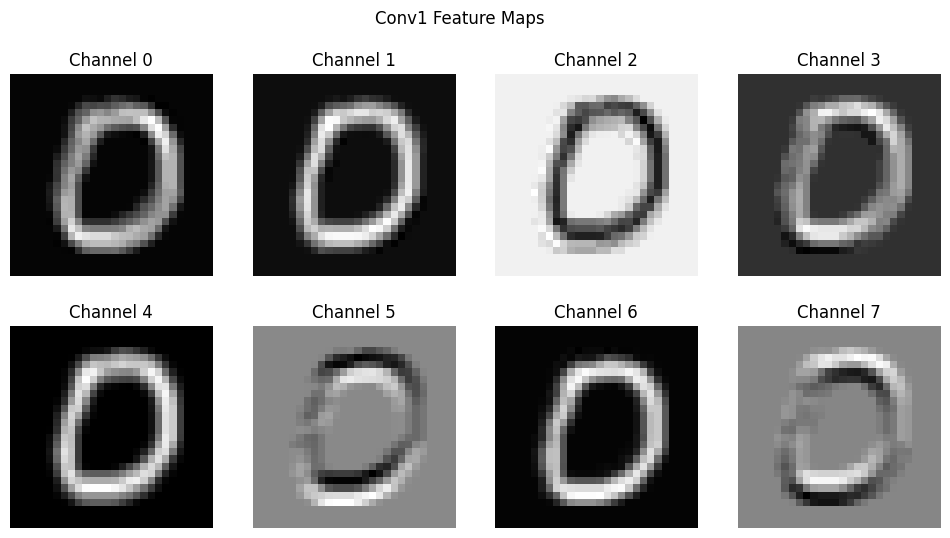

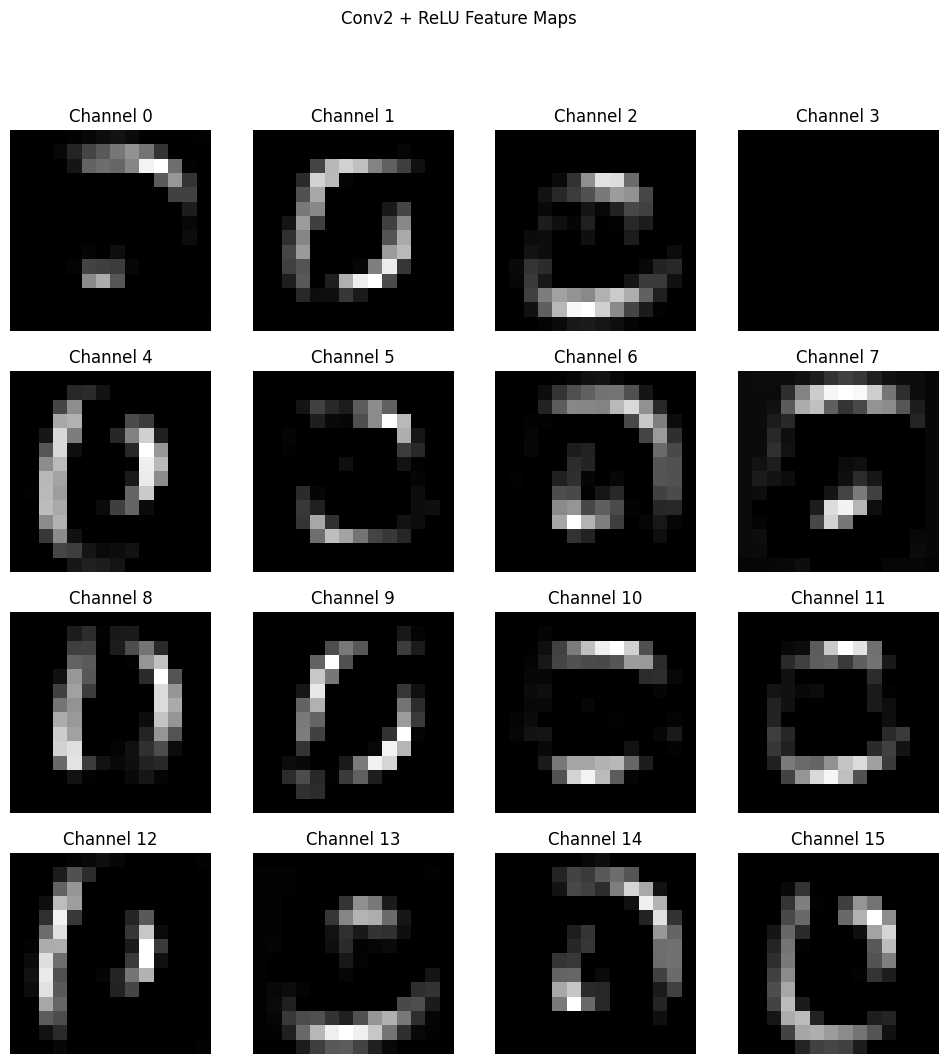

In [43]:
# TODO: CNN 각 층의 Feature Map 시각화
# TODO: cmap="viridis" 사용


# TODO: 이미지 선택
image, true_label = test_dataset[10] 
input_batch = image.unsqueeze(0).to(device)
# TODO: 역전파(파라미터 수정) 없이 순전파 수행
model.eval()

with torch.no_grad():
    logits, features = model(
        input_batch,
        return_features=True,
    )

# TODO: Conv1 Feature Maps 8개 시각화
show_feature_maps(
    features["conv1"],
    title="Conv1 Feature Maps",
    max_maps=8,
)

# TODO: Conv2 Feature Maps 16개 시각화
show_feature_maps(
    features["relu2"],
    title="Conv2 + ReLU Feature Maps",
    max_maps=16,
)

# TODO: 6개 Layer별 대표 Feature Map 4개씩 비교
layer_names = [
    "conv1",
    "relu1",
    "pool1",
    "conv2",
    "relu2",
    "pool2"
]

#### $18)$ 모델 저장 및 불러오기

학습이 완료된 모델을 추후에 사용하기 위해 저장하여 불러올 수 있습니다. 이를 통해 오래 걸리는 학습 과정을 반복하지 않아도 됩니다.

모델을 저장하고 재사용한다는 것은 결국 학습된 가중치를 보존한다는 의미입니다.

모델 저장:

In [40]:
torch.save(
    model.state_dict(),
    "src/models/MNIST/MNIST_CNN.pth",
)

모델 불러오기:

In [41]:
loaded_model = SimpleCNN()

state_dict = torch.load(
    "src/models/MNIST/MNIST_CNN.pth",
    map_location="cpu",
    weights_only=True,
)

loaded_model.load_state_dict(state_dict)
loaded_model.to(device)
loaded_model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

---

### G. GPU 병렬 연산 (CuPy)

GPU를 사용하여 기존 `NumPy` 배열 연산을 더욱 빠르게 수행할 수 있습니다. 그러기 위해서는 `NumPy`와 호환되는 GPU 배열 연산 라이브러리인 `CuPy`를 사용합니다.

`CuPy`:
* NumPy와 호환되는 GPU 배열 라이브러리
* NumPy와 유사한 문법으로 GPU 배열 연산
* NVIDIA CUDA를 활용하여 대규모 연산을 GPU에서 가속


현재 개발 환경인 JetPack 6.2, CUDA 12.6, NumPy 1.21.5에 맞춰 CuPy를 설치해야 합니다.

```bash
python -m pip download --no-deps --only-binary=:all: "cupy-cuda12x==12.3.0" -d ~/Downloads
python -m pip install --no-deps "fastrlock==0.8.3"
python -m pip install --no-deps --only-binary=:all: ~/Downloads/cupy_cuda12x-12.3.0-*.whl
```

설치가 제대로 되었는지 확인해봅시다.

In [44]:
import numpy as np
import cupy as cp

print("NumPy :", np.__version__)
print("CuPy  :", cp.__version__)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


NumPy : 1.26.4
CuPy  : 12.3.0


In [45]:
print("GPU count:", cp.cuda.runtime.getDeviceCount())
print("CUDA runtime:", cp.cuda.runtime.runtimeGetVersion())

x_cpu = np.arange(10)  # NumPy (host memory)
x_gpu = cp.arange(10)  # CuPy  (CUDA device memory)
y_cpu = x_cpu ** 2     # CPU에서 NumPy로 계산
y_gpu = x_gpu ** 2     # GPU에서 CuPy로 계산

cp.cuda.Stream.null.synchronize()

print("NumPy result:", y_cpu)
print("CuPy result:", y_gpu)

print("NumPy type:", type(y_cpu))
print("CuPy type:", type(y_gpu))

GPU count: 1
CUDA runtime: 12060
NumPy result: [ 0  1  4  9 16 25 36 49 64 81]
CuPy result: [ 0  1  4  9 16 25 36 49 64 81]
NumPy type: <class 'numpy.ndarray'>
CuPy type: <class 'cupy.ndarray'>


에러 없이 아래와 같은 결과가 출력되었다면 다음으로 넘어가도록 합시다.

```text
NumPy : 1.21.5
CuPy  : 12.3.0

GPU count: 1
CUDA runtime: 12060
NumPy result: [ 0  1  4  9 16 25 36 49 64 81]
CuPy result: [ 0  1  4  9 16 25 36 49 64 81]
NumPy type: <class 'numpy.ndarray'>
CuPy type: <class 'cupy.ndarray'>
```

#### $1)$ CuPy 개요

#### `NumPy` 배열:

In [46]:
x_cpu = np.array([1, 2, 3, 4])

print(type(x_cpu))
print(x_cpu)

<class 'numpy.ndarray'>
[1 2 3 4]


`NumPy`를 사용하여 정의한 데이터는 기본적으로 host(CPU) memory인 시스템 메모리(RAM)에 저장됩니다.

#### `CuPy` 배열:

In [47]:
x_gpu = cp.array([1, 2, 3, 4])

print(type(x_gpu))
print(x_gpu)

<class 'cupy.ndarray'>
[1 2 3 4]


#### $2)$ CPU(NumPy) vs. GPU(CuPy) 메모리

`CuPy`를 사용하여 정의한 데이터는 device(GPU) memory인 그래픽 메모리(VRAM)에 저장됩니다.

일반적인 경우에는 RAM과 VRAM이 분리되어 있지만, Jetson Orin Nano 같은 경우에는 메모리 칩을 공유하는 통합 메모리 아키텍쳐 (Unified Memory Architecture, UMA)를 사용합니다.

비록 물리적으로 나뉘어 있지는 않더라도, 통합 메모리 환경에서도 서로 다른 영역에 분리되어 있어 CPU와 GPU가 각자 할당된 메모리를 관리하며 `NumPy` 배열과 `CuPy` 배열을 함께 연산하려면 어느 한쪽의 메모리 공간으로 데이터를 먼저 복사해야 합니다.

#### CPU에서 GPU로 복사 (`NumPy` → `CuPy`):

In [48]:
x_from_cpu_to_gpu = cp.asarray(x_cpu)

print(type(x_from_cpu_to_gpu))
print(x_from_cpu_to_gpu)

<class 'cupy.ndarray'>
[1 2 3 4]


#### GPU에서 CPU로 복사 `CuPy` → `NumPy`:

In [49]:
x_from_gpu_to_cpu = cp.asnumpy(x_gpu)

print(type(x_from_gpu_to_cpu))
print(x_from_gpu_to_cpu)

<class 'numpy.ndarray'>
[1 2 3 4]


#### 잘못된 연산 예시:

In [52]:
try:
    y = x_cpu + x_gpu
except RuntimeError as e:
    print(f"잘못된 연산: {e}")

TypeError: Unsupported type <class 'numpy.ndarray'>

#### $3)$ NumPy와 CuPy 문법 비교:

`NumPy`:

In [53]:
x_cpu = np.array([1, 2, 3, 4])

total = np.sum(x_cpu)
maximum = np.max(x_cpu)
minimum = np.min(x_cpu)
mean = np.mean(x_cpu)
index = np.argmax(x_cpu)

print(total, maximum, minimum, mean, index)
print(type(total), type(maximum), type(minimum), type(mean), type(index))

10 4 1 2.5 3
<class 'numpy.int64'> <class 'numpy.int64'> <class 'numpy.int64'> <class 'numpy.float64'> <class 'numpy.int64'>


`CuPy`:

In [54]:
x_gpu = cp.array([1, 2, 3, 4])

total = np.sum(x_gpu)
maximum = np.max(x_gpu)
minimum = np.min(x_gpu)
mean = np.mean(x_gpu)
index = np.argmax(x_gpu)

print(total, maximum, minimum, mean, index)
print(type(total), type(maximum), type(minimum), type(mean), type(index))

total = cp.sum(x_gpu).item()
maximum = cp.max(x_gpu).item()
minimum = cp.min(x_gpu).item()
mean = cp.mean(x_gpu).item()
index = cp.argmax(x_gpu).item()

print(total, maximum, minimum, mean, index)
print(type(total), type(maximum), type(minimum), type(mean), type(index))

10 4 1 2.5 3
<class 'cupy.ndarray'> <class 'cupy.ndarray'> <class 'cupy.ndarray'> <class 'cupy.ndarray'> <class 'cupy.ndarray'>
10 4 1 2.5 3
<class 'int'> <class 'int'> <class 'int'> <class 'float'> <class 'int'>


`NumPy`:

In [55]:
a_cpu = np.random.rand(1000, 1000).astype(np.float32)
b_cpu = np.random.rand(1000, 1000,).astype(np.float32)

c_cpu = a_cpu @ b_cpu

print(c_cpu)

[[238.25557 245.5123  250.8636  ... 244.58849 244.45735 246.96585]
 [243.9837  251.71902 258.54385 ... 250.87389 251.26645 258.6236 ]
 [245.4783  253.98804 253.15652 ... 248.31508 248.89523 252.24026]
 ...
 [251.97684 258.29013 265.5218  ... 259.11914 258.14154 264.87903]
 [247.43973 260.42584 259.30707 ... 255.19418 256.68668 263.9227 ]
 [238.09575 253.34366 254.77039 ... 248.2792  246.58191 259.1262 ]]


`CuPy`:

In [56]:
a_gpu = cp.random.rand(1000, 1000, dtype=cp.float32)
b_gpu = cp.random.rand(1000, 1000, dtype=cp.float32)

c_gpu = a_gpu @ b_gpu

print(c_gpu)

[[256.394   256.01877 244.9813  ... 254.25418 245.46492 252.57504]
 [250.48547 248.47849 236.09549 ... 249.65662 238.43498 249.03598]
 [258.36316 257.56934 247.9746  ... 257.96713 248.65036 254.66212]
 ...
 [252.93843 255.01587 244.46155 ... 256.83118 243.23311 254.61124]
 [257.00122 251.95969 240.0123  ... 254.6523  242.24034 251.19316]
 [244.14554 243.87248 234.88876 ... 247.0363  239.35649 246.72684]]


`NumPy`:

In [57]:
import time


start = time.perf_counter()

y_cpu = x_cpu ** 2

end = time.perf_counter()

print(end - start)

0.00019415099995967466


`CuPy`:

In [58]:
import time


cp.cuda.Stream.null.synchronize()
start = time.perf_counter()

y_gpu = x_gpu ** 2

cp.cuda.Stream.null.synchronize()
end = time.perf_counter()

print(end - start)

0.0017374689996358939


`OpenCV` 및 `Matplotlib`:

```python
ret, frame = cap.read()              # NumPy, CPU

frame_gpu = cp.asarray(frame)        # CPU → GPU
result_gpu = frame_gpu ** 2          # GPU 연산
result_cpu = cp.asnumpy(result_gpu)  # GPU → CPU

cv2.imshow("Result", result_cpu)     # OpenCV (NumPy)
plt.imshow(result_cpu)               # Matplotlib (NumPy)
```

문법은 매우 비슷하지만 물리적으로 연산이 실행되는 장치가 다릅니다. `NumPy`는 CPU 코어, `CuPy`는 GPU 코어에서 연산이 일어납니다.

Jetson과 같이 CPU와 GPU가 물리적인 메모리를 공유하는 환경에서도, 두 장치의 연산 코어 수와 성능, 그리고 사용 목적은 엄연히 다릅니다.

Jetson Orin Nano에서는 `NumPy` 배열을 6개의 고성능 CPU 코어가 복잡하고 정교한 제어 흐름과 함께 순차적으로 연산을 처리하는 반면, `CuPy` 함수를 실행하면 1024개의 GPU 코어가 일제히 대규모 병렬 연산을 수행합니다.

#### $4)$ CuPy를 활용한 배열 연산 GPU 가속 1 – 이미지 잔상 효과 구현

`CuPy`를 사용하여 대규모 배열 연산이 GPU에서 어떻게 가속되는지 알아보겠습니다.

이번 실습에서는 이미지 배열을 여러 픽셀만큼 이동한 뒤, 각 이미지에 서로 다른 가중치를 곱하여 누적하는 이미지 잔상(Image Trail) 효과를 구현합니다.

#### 이미지 잔상 효과의 원리

원본 이미지를 오른쪽으로 조금씩 이동한 복사본들을 만들고, 각 복사본에 가중치를 곱한 뒤 모두 더합니다.

```text
원본 이미지 × weight[0]
오른쪽으로 1픽셀 이동한 이미지 × weight[1]
오른쪽으로 2픽셀 이동한 이미지 × weight[2]
오른쪽으로 3픽셀 이동한 이미지 × weight[3]
...
```

가중치는 이동 거리가 멀어질수록 작아지도록 설정합니다. 따라서 원본 이미지에 가까운 잔상은 선명하게 나타나고, 멀리 떨어진 잔상은 점점 흐리게 나타납니다.

예를 들어 입력 배열과 가중치가 다음과 같다고 가정합니다.

```text
입력 배열:  [10, 20, 30, 40, 50]
가중치:     [0.6, 0.3, 0.1]
```

각 이동 결과에 가중치를 곱하면 다음과 같습니다.

```text
이동 없음:      [10, 20, 30, 40, 50] × 0.6
오른쪽 1칸:     [ 0, 10, 20, 30, 40] × 0.3
오른쪽 2칸:     [ 0,  0, 10, 20, 30] × 0.1
```

이 결과들을 같은 위치끼리 더하면 오른쪽 방향으로 이어지는 잔상 효과가 만들어집니다.

#### CPU와 GPU의 처리 방식

NumPy를 사용하는 CPU 코드에서는 출력 이미지의 픽셀을 하나씩 순차적으로 계산합니다.

반면 CuPy를 사용하는 GPU 코드에서는 이동 횟수를 순차적으로 반복하되, 각 반복에서 이미지 배열 전체에 대한 곱셈과 덧셈을 GPU에서 병렬로 처리합니다.

* CPU
  * 출력 픽셀을 하나씩 순차적으로 계산
* GPU
  * 이동 횟수는 순차적으로 반복
  * 각 이동 단계의 전체 픽셀 연산은 병렬로 처리

**글로벌 변수 정의:**

In [59]:
IMAGE_PATH = "src/images/seagull.jpg"

TARGET_WIDTH = 1280
TARGET_HEIGHT = 720

TRAIL_LENGTH = 32

**이미지 불러오기:**

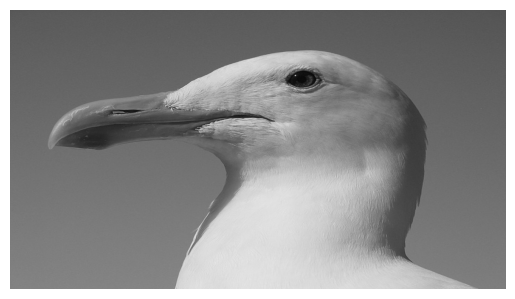

In [62]:
img_gray = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"이미지를 읽을 수 없습니다: {IMAGE_PATH}")

img_gray = cv2.resize(
    img_gray,
    (TARGET_WIDTH, TARGET_HEIGHT),
    interpolation=cv2.INTER_AREA
)

input_np = img_gray.astype(np.float32) / 255.0

plt.imshow(input_np, cmap="gray")
plt.axis("off");

**잔상 효과 함수 (CPU):**

In [64]:
def motion_trail_np(image, weights):
    """
    NumPy를 이용해 이미지 잔상 효과를 생성한다.

    출력 픽셀을 Python 반복문으로 하나씩 계산한다.
    """

    image_height, image_width = image.shape
    trail_length = len(weights)

    output = np.zeros((image_height, image_width), dtype=np.float32)

    for output_y in range(image_height):
        for output_x in range(image_width):
            weighted_sum = 0.0

            for shift in range(trail_length):
                input_x = output_x - shift

                if input_x >= 0:
                    weighted_sum += image[output_y, input_x] * weights[shift]

            output[output_y, output_x] = weighted_sum

    return output

**잔상 효과 함수 (GPU):**

In [68]:
# TODO: CuPy를 사용하여 잔상 효과 함수 정의

def motion_trail_cp(image, weights):
    """
    CuPy를 이용해 이미지 잔상 효과를 생성한다.

    이동 거리는 Python에서 순차적으로 반복하지만,
    각 이동 거리의 이미지 전체 계산은 GPU에서 병렬 처리한다.
    """

    # TODO: 필요한 변수 정의 및 출력 배열 생성
    image_height, image_width = image.shape
    trail_length = len(weights)
    output = cp.zeros((image_height, image_width),dtype=cp.float32)

    for shift in range(TRAIL_LENGTH):
        # TODO: 배열 slicing
        input_region = image[: , :image_width - shift]
        output_region = output[:, shift:]

        # TODO: GPU가 병렬 연산할 output_region 계산 코드
        output_region += input_region * weights[shift]

    return output

**가중치 설정:**

In [66]:
# 이동 거리가 멀어질수록 가중치를 작게 설정
weights_np = np.linspace(
    1.0,
    0.05,
    TRAIL_LENGTH,
    dtype=np.float32
)

# 전체 가중치의 합을 1로 정규화
weights_np /= np.sum(weights_np)

**NumPy CPU 처리:**

In [67]:
cpu_start = time.perf_counter()

output_np = motion_trail_np(
    image=input_np,
    weights=weights_np
)

cpu_end = time.perf_counter()

cpu_time = cpu_end - cpu_start

**CuPy 배열 준비:**

In [ ]:
# TODO: NumPy 배열을 CuPy 배열로 변환

upload_start = time.perf_counter()

input_cp = cp.asarray
weights_cp = cp.asarray

cp.cuda.Stream.null.synchronize()

upload_end = time.perf_counter()

upload_time = upload_end - upload_start

**GPU 워밍업:**

In [ ]:
warmup_image = cp.zeros((64, 64), dtype=cp.float32)
warmup_weights = cp.asarray(weights_np[:4])

_ = motion_trail_cp(
    image=warmup_image,
    weights=warmup_weights
)

cp.cuda.Stream.null.synchronize()

**CuPy GPU 처리:**

In [ ]:
cp.cuda.Stream.null.synchronize()

gpu_start = time.perf_counter()

output_cp = motion_trail_cp(
    image=input_cp,
    weights=weights_cp
)

cp.cuda.Stream.null.synchronize()

gpu_end = time.perf_counter()

gpu_time = gpu_end - gpu_start

**GPU 결과를 CPU로 가져오기:**

In [ ]:
# TODO: output_cp를 CPU 메모리로 복사

download_start = time.perf_counter()

output_cp_np = cp.asnumpy(output_cp)

download_end = time.perf_counter()

download_time = download_end - download_start

**결과 비교:**

In [ ]:
compute_speedup = cpu_time / gpu_time

gpu_total_time = upload_time + gpu_time + download_time
total_speedup = cpu_time / gpu_total_time

**결과 출력:**

In [ ]:
print("========== NumPy CPU ==========")
print(f"Processing time: {cpu_time:.4f} seconds")
print()

print("========== CuPy GPU ==========")
print(f"CPU to GPU: {upload_time:.4f} seconds")
print(f"GPU processing: {gpu_time:.4f} seconds")
print(f"GPU to CPU: {download_time:.4f} seconds")
print(f"Total GPU time: {gpu_total_time:.4f} seconds")
print()

print("========== Comparison ==========")
print(f"Compute-only speedup: {compute_speedup:.2f}x")
print(f"Including transfers: {total_speedup:.2f}x")

**이미지 출력:**

In [ ]:
plt.figure(figsize=(18,12))

plt.subplot(1,3,1), plt.imshow(input_np, cmap="gray"), plt.title("Original Image")
plt.subplot(1,3,2), plt.imshow(output_np, cmap="gray"), plt.title("Motion Trail (CPU)")
plt.subplot(1,3,3), plt.imshow(output_cp_np, cmap="gray"), plt.title("Motion Trail (GPU)")

for ax in plt.gcf().axes:
    ax.axis("off")

In [ ]:
plt.figure(figsize=(12,8))
plt.imshow(output_cp_np, cmap="gray")
plt.axis("off");

#### $5)$ CuPy를 활용한 배열 연산 GPU 가속 2 – Convolution 연산

이전 실습에서는 이미지 배열을 여러 픽셀만큼 이동하고, 각 배열에 서로 다른 가중치를 곱한 뒤 출력 배열에 누적하여 이미지 잔상 효과를 구현했습니다.

이 과정에서 이동 거리를 제어하는 for문은 Python에서 순차적으로 실행되지만, 각 반복에서 수행되는 이미지 배열 전체의 곱셈과 덧셈은 GPU에서 병렬로 처리된다는 점을 확인했습니다.

이번 실습에서는 이러한 배열 이동과 가중치 누적 방식을 2차원으로 확장하여 convolution 연산을 구현합니다.

이전에 정의한 `convolution2d()` 함수는 NumPy를 사용하여 출력 이미지의 픽셀을 하나씩 순차적으로 계산합니다.

각 출력 위치에서 커널 크기만큼 이미지 영역을 잘라낸 뒤, 이미지 영역과 커널을 원소별로 곱하고 그 결과를 모두 더하여 하나의 출력 픽셀을 생성합니다.

```text
출력 위치 하나 선택
→ 커널 크기의 이미지 영역 추출
→ 이미지 영역과 커널의 가중합 계산
→ 출력 픽셀 하나 저장
```

이 방식은 convolution의 원리를 직접 확인하기에는 적합하지만, 이미지의 높이와 너비만큼 Python 반복문을 실행해야 하므로 큰 이미지에서는 처리 시간이 오래 걸립니다.

<br>

이번에는 이전에 정의한 `convolution2d()` 함수와 동일한 결과를 계산하는 CuPy 기반의 `convolution2d_cp()` 함수를 작성합니다.

CuPy 버전에서는 출력 픽셀을 하나씩 반복하지 않고, 커널의 각 원소를 순차적으로 선택합니다. 그리고 모든 출력 위치에서 현재 커널 원소와 대응되는 입력 픽셀을 배열로 선택한 뒤, 해당 커널 가중치를 곱하여 출력 배열 전체에 누적합니다.

```text
커널 원소 하나 선택
→ 모든 출력 위치에서 대응되는 입력 픽셀 선택
→ 배열 전체에 현재 커널 가중치 적용
→ 출력 배열 전체에 누적
```

두 함수는 계산 순서가 다르지만, 최종적으로 각 출력 픽셀에는 이미지 영역과 커널의 동일한 가중합이 저장됩니다.

<br>

**함수의 입력으로는 이전 실습과 동일한 이미지를 사용합니다:**

In [ ]:
plt.imshow(input_np, cmap="gray")
plt.axis("off");

**Convolution 함수 정의 (CuPy):**

In [ ]:
# TODO: CuPy를 사용하여 2차원 convolution 함수 정의

# def convolution2d(image, kernel, bias=0.0, stride=1, padding=0):
#     """
#     2차원 이미지에 하나의 CNN 필터를 적용.

#     Parameters
#     ----------
#     image : np.ndarray
#         입력 이미지, shape = (height, width)
#     kernel : np.ndarray
#         CNN 필터, shape = (kernel_height, kernel_width)
#     bias : float
#         필터 출력에 더할 편향
#     stride : int
#         필터가 이동하는 간격
#     padding : int
#         입력 이미지 가장자리에 추가할 픽셀의 개수

#     Returns
#     -------
#     output : np.ndarray
#         편향까지 적용된 convolution 결과
#     """

#     image_height, image_width = image.shape
#     kernel_height, kernel_width = kernel.shape

#     # 이미지 가장자리에 zero padding 적용
#     padded_image = np.pad(
#         image,
#         ((padding, padding), (padding, padding)),
#         mode="constant",
#         constant_values=0
#     )

#     # (H, W: 입력 이미지 높이 및 너비, P: Padding 픽셀 값, S: Stride 픽셀 값)
#     # Convolution 출력 이미지 높이 = floor((H + 2P - K) / S) + 1
#     output_height = (padded_image.shape[0] - kernel_height) // stride + 1

#     # Convolution 출력 이미지 너비 = floor((W + 2P - K) / S) + 1
#     output_width = (padded_image.shape[1] - kernel_width) // stride + 1

#     # 계산한 크기로 출력 이미지 준비
#     output = np.zeros((output_height, output_width), dtype=np.float32)

#     # 커널을 움직이며 필터 적용
#     for output_y in range(output_height):
#         for output_x in range(output_width):
#             # 커널을 적용할 이미지 영역의 좌측상단
#             start_y = output_y * stride
#             start_x = output_x * stride

#             # 커널을 적용할 이미지 영역을 crop
#             image_region = padded_image[
#                 start_y:start_y + kernel_height,
#                 start_x:start_x + kernel_width
#             ]

#             # 필터를 적용하여 가중합 계산
#             weighted_sum = np.sum(image_region * kernel)

#             # 편향 적용
#             output[output_y, output_x] = weighted_sum + bias

#     return output

def convolution2d_cp(image, kernel, bias=0.0, stride=1, padding=0):
    """
    CuPy를 이용한 2차원 convolution.

    커널의 위치는 Python 반복문으로 순차 처리하고,
    각 위치에 해당하는 출력 배열 전체 연산은 GPU에서 처리한다.
    """
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    padded_image = cp.pad(
    image,
    ((padding, padding), (padding, padding)),
    mode="constant",
    constant_values=0
    )
    output_height = (padded_image.shape[0] - kernel_height) // stride + 1

    # Convolution 출력 이미지 너비 = floor((W + 2P - K) / S) + 1
    output_width = (padded_image.shape[1] - kernel_width) // stride + 1

    # 계산한 크기로 출력 이미지 준비
    output = cp.zeros((output_height, output_width), dtype=cp.float32)
    print(output_height)
    for output_y in range(output_height):
        for output_x in range(output_width):
    pass


**NumPy CPU 처리:**

In [ ]:
# TODO: 기존에 정의한 convolution2d 함수를 사용하여 convolution을 CPU로 처리
# TODO: 변수 재사용 가능

output_dx_np = ...
output_dy_np = ...
cpu_time = ...
relu_dx_np = ...
relu_dy_np = ...

**CuPy GPU 처리:**

In [ ]:
# TODO: convolution을 GPU로 처리 (변환-워밍업-처리 파이프라인 구현)
# TODO: 변수 재사용 가능

output_dx_cp = ...
output_dy_cp = ...
gpu_time = ...
relu_dx_cp_np = ...
relu_dy_cp_np = ...

**결과 출력:**

In [ ]:
# TODO: CPU/GPU 결과 비교 및 출력

**이미지 출력:**

In [ ]:
plt.figure(figsize=(18,8))

plt.subplot(2,3,1), plt.imshow(input_np, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,2), plt.imshow(relu_dx_np, cmap="gray"), plt.title("Vertical Convolution (CPU)")
plt.subplot(2,3,3), plt.imshow(relu_dx_cp_np, cmap="gray"), plt.title("Vertical Convolution (GPU)")
plt.subplot(2,3,4), plt.imshow(input_np, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,5), plt.imshow(relu_dy_np, cmap="gray"), plt.title("Horizontal Convolution (CPU)")
plt.subplot(2,3,6), plt.imshow(relu_dy_cp_np, cmap="gray"), plt.title("Horizontal Convolution (GPU)")

for ax in plt.gcf().axes:
    ax.axis("off")

---

### H. GPU 병렬 연산 (PyTorch)

#### $1)$ PyTorch 개요

GPU를 활용하면 배열 연산뿐만 아니라 딥러닝 모델의 학습과 추론도 빠르게 수행할 수 있습니다.

이를 위해 GPU 연산, 자동 미분, 신경망 모델 구성을 지원하는 딥러닝 프레임워크인 `PyTorch`를 사용합니다.

<br>

`PyTorch`:
* GPU 연산을 지원하는 오픈소스 딥러닝 프레임워크
* NumPy 배열과 유사한 다차원 배열인 Tensor 사용
* NVIDIA CUDA를 활용하여 딥러닝 연산을 GPU에서 가속
* 자동 미분을 통해 신경망의 가중치와 편향을 학습
* CNN, RNN, Transformer 등 다양한 딥러닝 모델 구현 가능

<br>

`PyTorch` 활용 사례:
* 이미지 분류
* 객체 검출
* 이미지 Segmentation
* 자세 추정
* 자연어 처리
* 음성 인식
* 생성형 AI
* 강화학습
* 로봇 인지
* Edge AI 추론

<br>

`PyTorch` 주요 기능:
* Tensor 연산
* 자동 미분
* 신경망 Layer, 손실 함수, Optimizer 제공
* 데이터 로딩 및 전처리
* 모델 구성 및 학습
* 모델 저장 및 불러오기

#### $2)$ PyTorch 기본 문법

**`PyTorch` 주요 구성 요소:**

* 다차원 배열
```text
    torch.Tensor
```

* 자동 미분과 Gradient 계산
```text
    torch.autograd
    torch.no_grad
    torch.enable_grad
```

* 신경망 Layer와 Loss Function
```text
    torch.nn
    torch.nn.functional
```

* SGD, Adam 등의 Optimizer
```text
    torch.optim
```

* Dataset과 DataLoader
```text
    torch.utils.data
```

* PyTorch의 컴퓨터 비전 라이브러리 (이미지 Dataset, Transform, 모델)
```text
    torchvision
```

**a) 기본적인 Import:**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

**b) CPU Tensor 생성:**

In [ ]:
x_cpu = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]])

print(x_cpu)
print(x_cpu.device)

**c) GPU Tensor 생성:**

In [ ]:
if torch.cuda.is_available():
    x_gpu = x_cpu.to("cuda")

    print(x_gpu)
    print(x_gpu.device)

**d) Device 설정:**

In [ ]:
device = torch.device("cpu")

print("Selected device:", device)

In [ ]:
device = torch.device("cuda")

print("Selected device:", device)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("CUDA Availability:", torch.cuda.is_available())
print("Selected device:", device)

**e) 모델 생성 및 장치 할당:**

앞선 실습에서 정의한 `SimpleCNN` 클래스를 다시 보도록 합시다.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        self.fc1 = nn.Linear(
            16 * 7 * 7,
            64,
        )

        self.fc2 = nn.Linear(
            64,
            10,
        )

    def forward(self, x, return_features=False):
        conv1_output = self.conv1(x)
        relu1_output = F.relu(conv1_output)
        pool1_output = self.pool(relu1_output)
        conv2_output = self.conv2(pool1_output)
        relu2_output = F.relu(conv2_output)
        pool2_output = self.pool(relu2_output)
        flattened = torch.flatten(pool2_output, start_dim=1)
        fc1_output = F.relu(self.fc1(flattened))
        logits = self.fc2(fc1_output)

        if return_features:
            features = {
                "conv1": conv1_output,
                "relu1": relu1_output,
                "pool1": pool1_output,
                "conv2": conv2_output,
                "relu2": relu2_output,
                "pool2": pool2_output,
            }

            return logits, features

        return logits

In [ ]:
# 모델 생성
model = SimpleCNN()

# 모델을 장치에 할당
model = model.to(device)

print("Device:", device)
print(model)

**f) 데이터셋 불러오기:**

데이터셋의 원본은 이미지입니다. 이미지는 기본적으로 ‘높이 × 너비 × 채널’ 구조로 존재합니다. 하지만 PyTorch 모델은 계산 효율을 위해 ‘채널 × 높이 × 너비’ 형태로 입력을 받습니다.

또한, 원본 이미지는 0 ~ 255 사이의 정수값을 가지는 반면, PyTorch 모델은 학습의 안정성을 위해 0.0 ~ 1.0 사이의 실수값을 요구합니다.

이때 `transforms.ToTensor()`라는 변환기를 사용하면, 이미지 형식을 PyTorch 모델에 맞춘 최적의 형식으로 자동 변환할 수 있습니다.

<br>

구체적으로는 다음 두 가지 중요한 일을 자동으로 처리합니다.
* 형태 변환: 일반 이미지 파일 형식(H, W, C)을 PyTorch 연산 표준인 (C, H, W) 구조로 순서를 변경
* 스케일링: 0~255 사이의 정수로 표현된 픽셀 값을 0.0~1.0 사이의 실수(Float32) 값으로 자동 변환(정규화)

해당 과정은 딥러닝 모델의 안정적인 학습을 위해 필수입니다.

In [ ]:
# 이미지 데이터를 PyTorch 모델이 학습할 수 있는 텐서(Tensor) 형태로 변환하는 변환기 생성
transform = transforms.ToTensor()

In [ ]:
# 학습 데이터 불러오기
train_dataset = datasets.MNIST(
    root="src/datasets",  # 데이터셋을 저장 및 불러오기 위한 디렉토리
    train=True,           # 학습용 데이터만 불러오는 설정
    transform=transform,  # 텐서 변환기를 데이터셋에 적용
    download=True,        # 지정한 경로에 데이터가 없으면 자동으로 다운로드
)

# 테스트 데이터 불러오기
test_dataset = datasets.MNIST(
    root="src/datasets",  # 데이터셋 디렉토리
    train=False,          # 학습용/테스트용 데이터 로드 설정
    transform=transform,  # 텐서 변환기
    download=True,        # 최초 다운로드
)

**g) DataLoader 생성:**

DataLoader의 역할:
* Dataset은 이미지 한 장과 Label 하나를 반환 (`image, label = train_dataset[0]`)
* DataLoader는 총 70,000개의 데이터를 지정한 사이즈의 하나의 묶음(Batch)으로 불러와 모델에 전달
* 실제 학습에서는 한 장씩 모델에 입력 값으로 전달하기 보다는, 여러 이미지를 하나의 Batch로 묶어서 입력에 전달한다

DataLoader이 제공하는 기능:
* Batch 생성
* Batch 단위 반복
* 데이터 순서 섞기
* 데이터 로딩 과정 관리

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=0,
)

**h) 데이터셋의 단일 image/label 확인:**

In [ ]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)
print("Minimum:", image.min().item())
print("Maximum:", image.max().item())

image_2d = image.squeeze(0)

plt.imshow(image_2d, cmap="gray"), plt.title(f"Label: {label}")
plt.axis("off");

**i) 데이터셋을 GPU에 할당:**

DataLoader를 '반복자(Iterator)'로 변환한 뒤, 첫 번째 Batch만 불러오기:

In [ ]:
images, labels = next(iter(train_loader))

print(type(images))
print(type(labels))
print()
print("이미지 Batch 형태:", images.shape)
print()
print("레이블 Batch 텐서 :\n", labels)

이미지와 레이블 Batch 텐서를 장치(GPU)에 할당:

In [ ]:
print("images 텐서의 과거 위치:", images.device)
print("labels 텐서의 과거 위치:", labels.device)

images = images.to(device)
labels = labels.to(device)

print("images 텐서의 현재 위치:", images.device)
print("labels 텐서의 현재 위치:", labels.device)

***※ 주의: 모델과 Tensor는 같은 Device에 있어야 한다***

In [ ]:
model = SimpleCNN()
model = model.to(device)

print("모델 위치:", device)

In [ ]:
images, labels = next(iter(train_loader))

print("입력 이미지 텐서 위치:", images.device)

In [ ]:
try:
    outputs = model(images)
except RuntimeError as e:
    print(f"예러: {e}")

---

### I. MNIST 데이터셋 GPU 가속 학습

#### $1)$ 딥러닝 학습 구조 복습

앞선 MNIST 손글씨 분류 실습에서 확인한 바와 같이, 하나의 Batch 학습 과정은 다음과 같습니다.

1. 이미지와 Label 준비
2. 순전파로 결과 예측
3. Loss 계산
4. 기존 Gradient 초기화
5. 역전파 수행
6. Optimizer로 Weight 수정

#### $2)$ CPU 기반 MNIST 데이터셋 학습

MNIST 실습에서 사용된 코드를 종합하면 아래와 같이 작성할 수 있습니다.

In [ ]:
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


SEED = 42
DATA_ROOT = "src/datasets"

BATCH_SIZE = 64
TEST_BATCH_SIZE = 1000
EPOCHS = 3
LEARNING_RATE = 0.001
NUM_WORKERS = 0


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        self.fc1 = nn.Linear(
            16 * 7 * 7,
            64,
        )

        self.fc2 = nn.Linear(
            64,
            10,
        )

    def forward(self, x, return_features=False):
        conv1_output = self.conv1(x)
        relu1_output = F.relu(conv1_output)
        pool1_output = self.pool(relu1_output)
        conv2_output = self.conv2(pool1_output)
        relu2_output = F.relu(conv2_output)
        pool2_output = self.pool(relu2_output)
        flattened = torch.flatten(pool2_output, start_dim=1)
        fc1_output = F.relu(self.fc1(flattened))
        logits = self.fc2(fc1_output)

        if return_features:
            features = {
                "conv1": conv1_output,
                "relu1": relu1_output,
                "pool1": pool1_output,
                "conv2": conv2_output,
                "relu2": relu2_output,
                "pool2": pool2_output,
            }

            return logits, features

        return logits


def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # 모델을 학습 모드(training mode)로 변경
    model.train()

    # 결과를 누적하기 위한 변수
    total_loss = 0.0
    correct_count = 0
    sample_count = 0

    # 학습 데이터를 DataLoader(train_loader)의 Batch 단위로 불러와 학습 반복
    for images, labels in data_loader:
        # 장치(CPU/GPU)로 이동
        images = images.to(device)
        labels = labels.to(device)

        # Gradient 초기화 (이전 Batch에서 계산한 Gradient를 제거)
        optimizer.zero_grad()

        # 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
        logits = model(images)

        # Loss 계산
        loss = criterion(logits, labels)
        # 역전파를 통한 Gradient 계산
        loss.backward()
        # Gradient를 사용하여 파라미터 수정
        optimizer.step()

        # Batch 한 개의 이미지 개수
        batch_size = images.size(0)

        # 결과 누적
        total_loss += loss.item() * batch_size                 # Loss 누적 (1개 batch의 평균 loss x batch 크기)
        predictions = logits.argmax(dim=1)                     # 가장 높은 점수를 가진 클래스를 선택
        correct_count += (predictions == labels).sum().item()  # 정답을 맞춘 개수 계산
        sample_count += batch_size                             # 전체 샘플 수 누적

    # 평균 Loss 및 Accuracy 계산
    average_loss = total_loss / sample_count
    accuracy = correct_count / sample_count

    return average_loss, accuracy


def evaluate(model, data_loader, criterion, device):
    # 모델을 평가 모드(evaluation mode)로 변경
    model.eval()

    # 결과를 누적하기 위한 변수
    total_loss = 0.0
    correct_count = 0
    sample_count = 0

    # Gradient 계산을 비활성화 (파라미터 수정 비활성화)
    with torch.no_grad():
        # 평가 데이터를 DataLoader(test_loader)의 Batch 단위로 불러와 평가 반복
        for images, labels in data_loader:
            # 장치(CPU/GPU)로 이동
            images = images.to(device)
            labels = labels.to(device)

            # 학습된 모델의 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
            logits = model(images)

            # Loss 계산 (역전파는 수행하지 않음)
            loss = criterion(logits, labels)

            # Batch 한 개의 이미지 개수
            batch_size = images.size(0)

            # 결과 누적
            total_loss += loss.item() * batch_size                 # Loss 누적 (1개 batch의 평균 loss x batch 크기)
            predictions = logits.argmax(dim=1)                     # 가장 높은 점수를 가진 클래스를 선택
            correct_count += (predictions == labels).sum().item()  # 정답을 맞춘 개수 계산
            sample_count += batch_size                             # 전체 샘플 수 누적

        # 평균 Loss 및 Accuracy 계산
        average_loss = total_loss / sample_count
        accuracy = correct_count / sample_count

        return average_loss, accuracy


def main_cpu():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    transform = transforms.ToTensor()

    train_dataset = datasets.MNIST(
        root=DATA_ROOT,
        train=True,
        transform=transform,
        download=True,
    )

    test_dataset = datasets.MNIST(
        root="src/datasets",
        train=False,
        transform=transform,
        download=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=TEST_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    device = torch.device("cpu")

    model = SimpleCNN()
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    train_loss_history = []
    train_accuracy_history = []
    test_loss_history = []
    test_accuracy_history = []

    training_start_time = time.perf_counter()

    for epoch in range(EPOCHS):
        epoch_start_time = time.perf_counter()

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        test_loss, test_accuracy = evaluate(
            model,
            test_loader,
            criterion,
            device,
        )

        train_loss_history.append(train_loss)
        train_accuracy_history.append(train_accuracy)
        test_loss_history.append(test_loss)
        test_accuracy_history.append(test_accuracy)

        epoch_time = time.perf_counter() - epoch_start_time

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train accuracy: "
            f"{train_accuracy * 100:.2f}% | "
            f"Test loss: {test_loss:.4f} | "
            f"Test accuracy: "
            f"{test_accuracy * 100:.2f}% | "
            f"Time: {epoch_time:.2f}s"
        )

    total_training_time = time.perf_counter() - training_start_time
    print(f"Total CPU training time: {total_training_time:.2f}s")

    return total_training_time

#### $3)$ GPU 기반 MNIST 데이터셋 학습

CPU 기반 MNIST 데이터셋 학습 코드를 복습하며 GPU 기반 학습 코드를 작성해봅시다.

`CuPy` 실습에서 GPU 연산 처리 시간을 측정하기 위해 GPU의 모든 작업이 완료될 때까지 CPU가 기다리도록 하는 동기화 함수인 `cp.cuda.Stream.null.synchronize()` 대신, `PyTorch`에서는 `torch.cuda.synchronize()` 함수를 사용합니다.

In [ ]:
# TODO: GPU 기반 MNIST 데이터셋 학습 코드 작성

def main_gpu():
    pass

**데이터셋 학습 및 결과 비교:**

In [ ]:
if __name__ == "__main__":
    print("=== CPU Training ===")
    cpu_training_time = main_cpu()

    print("\n=== GPU Training ===")
    gpu_training_time = main_gpu()

    speedup = cpu_training_time / gpu_training_time
    time_difference = cpu_training_time - gpu_training_time

    print("\n=== CPU vs. GPU Comparison ===")
    print(f"CPU training time: {cpu_training_time:.2f}s")
    print(f"GPU training time: {gpu_training_time:.2f}s")
    print(f"Time difference: {time_difference:.2f}s")
    print(f"GPU speedup: {speedup:.2f}x")

---

### J. CIFAR-10 이미지 분류 GPU 가속 학습

앞에서는 MNIST 데이터셋을 사용하여 흑백 손글씨 숫자를 분류하는 CNN 모델을 구현했습니다.

이번 실습에서는 CIFAR-10 데이터셋을 사용하여 비행기, 자동차, 새, 고양이 등 실제 사물 이미지를 분류합니다.

CIFAR-10은 MNIST보다 이미지의 구조와 배경이 복잡하며, RGB 컬러 이미지로 구성되어 있어 분류 난이도가 더 높습니다.

#### $1)$ 필수 라이브러리 import

필수 라이브러리는 MNIST 실습과 동일합니다.

In [ ]:
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### $2)$ 난수 고정

MNIST 실습과 동일하게 난수를 고정합니다.

In [ ]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed);

#### $3)$ 데이터 전처리

기존 MNIST 실습에서는 `transforms.ToTensor()`를 사용하여 이미지를 PyTorch 모델이 처리할 수 있는 Tensor로 변환했습니다. 이 과정에서 이미지의 차원 순서가 (H, W, C)에서 PyTorch가 사용하는 (C, H, W) 형식으로 변경되고, 픽셀값도 일반적으로 0~255에서 0.0~1.0 범위로 변환됩니다.

CIFAR-10 데이터셋 역시 CNN 모델에 입력하기 위해 이러한 변환 과정이 필요합니다.

그러나 MNIST는 대부분 숫자가 이미지 중앙에 위치하고 배경도 단순하기 때문에 비교적 분류하기 쉬운 데이터셋입니다. 반면 CIFAR-10은 객체의 위치와 방향이 다양하고 배경도 복잡하며, 같은 클래스의 이미지라도 형태와 색상이 크게 다를 수 있습니다.

따라서 CIFAR-10은 MNIST보다 학습 난이도가 높고, 모델이 학습 데이터의 특정 위치나 방향, 배경에 과도하게 맞춰지는 과적합이 발생할 가능성도 더 큽니다.

이를 완화하기 위해 '데이터 증강(Data Augmentation)'을 사용합니다. 데이터 증강은 학습할 때마다 원본 이미지의 위치나 방향 등을 조금씩 변형하여 새로운 이미지처럼 사용하는 방법입니다. 이를 통해 CNN이 학습 이미지의 특정 형태를 단순히 외우는 대신, 객체를 구분하는 핵심적인 특징을 학습하도록 도울 수 있습니다.

또한 학습을 더욱 안정적으로 진행하기 위해 CNN에 입력되는 픽셀값의 분포를 조정하는 **정규화(Normalization)**를 적용합니다. 정규화는 각 RGB 채널의 픽셀값에서 평균을 빼고 표준편차로 나누어, 채널별 입력값이 비슷한 범위와 분포를 가지도록 만드는 과정입니다.

이를 통해 RGB 채널 사이의 값 분포 차이를 줄이고, Gradient가 지나치게 불안정하게 변하는 현상을 완화할 수 있습니다. 또한 Optimizer가 Weight와 Bias를 보다 안정적으로 수정하도록 도와 학습 초기의 안정성을 높이고, 모델이 더 빠르게 수렴하는 데 도움을 줄 수 있습니다.

요약하면 다음과 같습니다.

* 데이터 증강 (Data Augmentation)
  * 학습 이미지의 위치나 방향 등을 무작위로 변형
  * 데이터의 다양성 향상
  * 모델이 특정 이미지 형태를 외우는 과적합을 완화
* 정규화 (Normalization)
  * 채널별 픽셀값의 분포를 일정한 기준으로 조정
  * Gradient와 Optimizer의 기능을 안정화
  * 학습 효율 향상

**a) CIFAR-10 데이터 정규화 정보:**

입력(학습/테스트) 이미지를 정규화하기 위해 CIFAR-10 채널 평균과 표준편차를 사용합니다.

CIFAR-10 이미지의 채널별 통계를 미리 계산한 값으로 PyTorch 공식 자료에서 제공합니다.

In [ ]:
CIFAR10_MEAN = (
    0.4914,
    0.4822,
    0.4465,
)

CIFAR10_STD = (
    0.2470,
    0.2435,
    0.2616,
)

**b) 데이터 증강:**

데이터 증강은 2가지 방법을 사용합니다.
1. RandomCrop: 이미지가 조금씩 상하좌우로 이동한 것과 같은 효과로 변형
2. RandomHorizontalFlip: 특정 확률로 이미지를 좌우 반전

데이터 증강은 일반적으로 학습 데이터에만 적용합니다.

In [ ]:
transforms.RandomCrop(size=32, padding=4)
transforms.RandomHorizontalFlip(p=0.5);

**c) 정규화:**

CNN의 입력값 분포를 일정하게 만들어 학습을 더 안정적으로 진행하기 위해 입력 이미지를 정규화합니다.

정규화는 모델이 학습할 때와 평가할 때 동일한 입력 분포를 받도록 학습 데이터와 테스트 데이터 모두에 같은 기준으로 적용해야 합니다.

In [ ]:
transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD);

**d) 데이터 전처리 최종 코드:**

In [ ]:
CIFAR10_MEAN = (
    0.4914,
    0.4822,
    0.4465,
)

CIFAR10_STD = (
    0.2470,
    0.2435,
    0.2616,
)

train_transform = transforms.Compose([
    transforms.RandomCrop(size=32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

#### $4)$ CIFAR-10 데이터셋 설치 및 불러오기

데이터셋 로드 방식은 MNIST와 동일하며, 데이터셋 이름만 `datasets.CIFAR10`으로 변경해줍니다.

In [ ]:
train_dataset = datasets.CIFAR10(
    root="src/datasets",
    train=True,
    transform=train_transform,
    download=True,
)

test_dataset = datasets.CIFAR10(
    root="src/datasets",
    train=False,
    transform=test_transform,
    download=True,
)

CIFAR-10 데이터셋이 정상적으로 설치되었는지 아래 코드를 통해 확인합니다.

MNIST와 마찬가지로 학습 데이터는 50000개, 테스트 데이터는 10000개 입니다.

In [ ]:
print(
    "Train data:",
    len(train_dataset)
)

print(
    "Test data:",
    len(test_dataset)
)

#### $5)$ CIFAR-10 데이터 확인

설치된 CIFAR-10 데이터를 확인해봅시다.

In [ ]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)
print("Minimum:", image.min().item())
print("Maximum:", image.max().item())

CIFAR-10은 텐서 타입으로 이미지가 RGB 3채널에 크기는 32x32로 아래와 같은 결과가 나와야 정상입니다.
```text
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 32, 32])
```

또한, 정규화를 거친 데이터이기에 Minimum과 Maximum이 -2.0 ~ 2.0으로 나옵니다.

그 이유는 PyTorch에서 제공한 평균과 표준편차를 적용하면 RGB 각 최댓값/최솟값이 다음과 같이 계산되기 때문입니다.
* R: -1.989 ~ 2.059
* G: -1.980 ~ 2.126
* B: -1.707 ~ 2.116

#### $6)$ CIFAR-10 데이터 시각화

CIFAR-10 이미지 한 장을 시각화해 봅시다.

In [ ]:
CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

plt.figure(figsize=(15,10))

for index in range(20):
    image, label = train_dataset[index]
    image_rgb = image.permute(1, 2, 0)
    plt.subplot(4,5,index+1), plt.imshow(image_rgb), plt.title(f"Label: {CIFAR10_CLASSES[label]}")
    plt.axis("off");

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).<br>
이 메세지는 RGB 값 범위가 [0.0, 1.0]에서 벗어났기 때문입니다.

정규화를 통해 안정적인 학습에는 도움이 되지만, 시각화를 위해 역정규화가 필요합니다.

In [ ]:
mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
std = torch.tensor(CIFAR10_STD).view(3, 1, 1)

plt.figure(figsize=(15,10))

for index in range(20):
    image, label = train_dataset[index]
    image_denormalized = image * std + mean
    image_rgb = image_denormalized.permute(1, 2, 0).clamp(0, 1)
    plt.subplot(4,5,index+1), plt.imshow(image_rgb), plt.title(f"Label: {CIFAR10_CLASSES[label]}")
    plt.axis("off");

#### $7)$ DataLoader 생성

CIFAR-10 데이터는 MNIST보다 이미지 크기도 크며 색상 채널이 존재하기에 Batch 크기를 줄여줍시다.

In [ ]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [ ]:
images, labels = next(
    iter(train_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

images, labels = next(
    iter(test_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

#### $8)$ CNN 모델 정의

CIFAR-10은 MNIST보다 이미지의 색상, 배경, 객체의 형태와 위치가 훨씬 다양합니다. 따라서 MNIST에서 사용한 단순한 CNN보다 더 많은 Channel과 Convolution Layer를 사용하여 다양한 수준의 특징을 충분히 추출할 필요가 있습니다.

CNN의 앞부분에서는 선, 경계, 색상 변화처럼 비교적 단순한 특징을 추출하고, Layer가 깊어질수록 질감, 사물의 부분적인 형태, 객체 전체의 구조처럼 더 복잡한 특징을 학습합니다. 또한 Channel 수를 점차 증가시키면 각 단계에서 더 다양한 종류의 Feature Map을 생성할 수 있습니다.

```text
64 Channels
→ 비교적 단순한 색상과 경계 특징 추출

128 Channels
→ 질감과 부분적인 형태 추출

256 Channels
→ 객체를 구분하기 위한 복잡한 특징 추출
```
<br>

이번 CIFAR-10 모델에서는 MNIST의 `SimpleCNN`에 없었던 `BatchNorm2d`, `AdaptiveAvgPool2d`, `Dropout`도 추가합니다. 이러한 Layer들은 CIFAR-10에 반드시 필요한 것은 아니지만, 더 깊고 복잡한 CNN을 안정적으로 학습하고 과적합을 완화하는 데 도움을 줍니다.

* `BatchNorm2d`:
  * Convolution Layer의 출력 분포를 조정하여 학습을 안정화
  * 각 Batch의 Feature Map을 정규화
* `AdaptiveAvgPool2d`:
  * 각 Feature Map의 공간 영역을 평균값 하나로 압축
  * 256 × 4 × 4 Feature Map을 256 × 1 × 1로 변환
  * FC Layer에 전달할 Feature 수와 파라미터 수 감소
* `Dropout`:
  * 학습 과정에서 일부 Feature를 무작위로 비활성화
  * 모델이 특정 Feature에 지나치게 의존하는 것을 방지하고 과적합을 완화

<br>CIFAR-10을 분류하기 위한 CNN 구조를 아래와 같이 구성합니다.

<div style="text-align: center;">
  [입력]<br>
  3 × 32 × 32<br>
  ↓<br><br>

  [Conv1-1]<br>
  64 × 32 × 32<br>
  ↓<br>
  [Batch Normalization]<br>
  64 × 32 × 32<br>
  ↓<br>
  [ReLU]<br>
  64 × 32 × 32<br>
  ↓<br>
  [Conv1-2]<br>
  64 × 32 × 32<br>
  ↓<br>
  [Batch Normalization]<br>
  64 × 32 × 32<br>
  ↓<br>
  [ReLU]<br>
  64 × 32 × 32<br>
  ↓<br>
  [Max Pooling]<br>
  64 × 16 × 16<br>
  ↓<br><br>

  [Conv2-1]<br>
  128 × 16 × 16<br>
  ↓<br>
  [Batch Normalization]<br>
  128 × 16 × 16<br>
  ↓<br>
  [ReLU]<br>
  128 × 16 × 16<br>
  ↓<br>
  [Conv2-2]<br>
  128 × 16 × 16<br>
  ↓<br>
  [Batch Normalization]<br>
  128 × 16 × 16<br>
  ↓<br>
  [ReLU]<br>
  128 × 16 × 16<br>
  ↓<br>
  [Max Pooling]<br>
  128 × 8 × 8<br>
  ↓<br><br>

  [Conv3-1]<br>
  256 × 8 × 8<br>
  ↓<br>
  [Batch Normalization]<br>
  256 × 8 × 8<br>
  ↓<br>
  [ReLU]<br>
  256 × 8 × 8<br>
  ↓<br>
  [Conv3-2]<br>
  256 × 8 × 8<br>
  ↓<br>
  [Batch Normalization]<br>
  256 × 8 × 8<br>
  ↓<br>
  [ReLU]<br>
  256 × 8 × 8<br>
  ↓<br>
  [Max Pooling]<br>
  256 × 4 × 4<br>
  ↓<br><br>

  [Global Average Pooling]<br>
  256 × 1 × 1<br>
  ↓<br>
  [Flatten]<br>
  256<br>
  ↓<br>
  [Dropout]<br>
  256<br>
  ↓<br>
  [Fully Connected]<br>
  10
</div>

우선, CNN 구조에서 반복되는 층(Layers)을 재사용하기 위해 하나의 클래스로 만들어줍니다. CIFAR-10의 CNN 구조에서 반복되는 구간은 다음과 같습니다.

<br>
<div style="text-align: center;">
  Convolution → Batch Normalization → ReLU  → Convolution → Batch Normalization → ReLU → Max Pooling
</div>
<br>

In [ ]:
class ConvBlock(nn.Module):
    """
    Convolution을 이용해 특징을 추출하고 Max Pooling을 적용하는 재사용 가능한 CNN 블록.

    기본 구조:
    Conv2d → BatchNorm2d → ReLU
    → Conv2d → BatchNorm2d → ReLU
    → MaxPool2d
    """
    
    def __init__(self, in_channels, out_channels):
        super().__init__()

         # Block을 구성할 Layer들을 순서대로 저장
        layers = [

            # 첫 번째 Convolution (특징 추출)
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            # 각 출력 채널의 값 분포를 조정하여 학습 안정화
            nn.BatchNorm2d(out_channels),

            # ReLU 활성화 함수
            nn.ReLU(),

            # 두 번째 Convolution (특징 추가적으로 추출)
            nn.Conv2d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),

            # 두 번째 Convolution의 출력을 정규화
            nn.BatchNorm2d(out_channels),

            # 두 번째 활성화 함수를 적용
            nn.ReLU(),

            # Max Pooling 적용하여 다운스케일
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,
            )
            
        ]

        # 리스트에 저장한 Layer들을 순서대로 실행하는 하나의 Sequential Module로 구성
        self.block = nn.Sequential(*layers)

    # 입력 x를 self.block의 Layer에 순서대로 전달
    def forward(self, x):
        return self.block(x)

위에서 정의한 CNN 블록을 사용하여 CIFAR-10 분류 모델을 정의합니다.

In [ ]:
class CIFAR10CNN(nn.Module):
    """
    CIFAR-10의 32x32 RGB 이미지를 10개 클래스로 분류하는 CNN 모델.

    전체 구조:
    ConvBlock 1
    → ConvBlock 2
    → ConvBlock 3
    → Global Average Pooling
    → Dropout
    → Linear
    """

    def __init__(self):
        super().__init__()

        # 이미지에서 특징을 추출하는 부분 (ConvBlock 1 → ConvBlock 2 → ConvBlock 3)
        self.features = nn.Sequential(

            
            ConvBlock(                 # 출력: [Batch, 64, 16, 16]
                in_channels=3,
                out_channels=64,
            ),

            
            ConvBlock(                 # 출력: [Batch, 128, 8, 8]
                in_channels=64,
                out_channels=128,
            ),

            
            ConvBlock(                 # 출력: [Batch, 256, 4, 4]
                in_channels=128,
                out_channels=256,
            ),

        )

        # 각 4×4 Feature Map의 평균을 계산하여 공간 크기를 1×1로 압축
        self.global_average_pool = (
            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)     # 출력: [Batch, 256, 1, 1]
                )
        )

        # 추출된 특징을 이용해 최종 클래스를 예측
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),         # 출력: 256

            nn.Linear(                 # 출력: 10
                in_features=256,
                out_features=10,
            ),
        )

    # 입력 이미지: [Batch, 3, 32, 32]
    def forward(self, x):
        # 세 개의 ConvBlock을 통과하며 특징을 추출
        # 출력: [Batch, 256, 4, 4]
        x = self.features(x)

        # 각 채널의 4×4 값을 평균내어 1×1로 압축
        # 출력: [Batch, 256, 1, 1]
        x = self.global_average_pool(x)

        # Tensor를 2차원으로 펼침
        # [Batch, 256, 1, 1] → [Batch, 256]
        x = torch.flatten(x, start_dim=1)

        # 각 클래스에 대한 점수인 Logit을 계산
        # 출력: [Batch, 10]
        logits = self.classifier(x)

        return logits

모델을 정의했으니, 시각화하여 확인해봅시다.

In [ ]:
model_struct = visualize_model(CIFAR10CNN(), (1,3,32,32))

plt.figure(figsize=(15,6))
plt.imshow(model_struct)
plt.axis("off");

#### $9)$ 모델 생성 및 GPU 지정

이번 이미지 분류 작업은 학습할 파라미터 수가 매우 많아 오직 GPU에서만 진행합니다.

먼저 모델을 생성하고 GPU로 옮겨주겠습니다.

In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU를 사용할 수 없습니다."
    )

device = torch.device("cuda")
model = CIFAR10CNN().to(device)

print("Device:", device)
print(model)

모델이 학습할 파라미터 수를 확인해봅시다.

In [ ]:
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", parameter_count)
print("Trainable parameters:", trainable_parameter_count)

#### $10)$ 손실 함수 및 Optimizer 설정

CIFAR-10 학습에서는 MNIST 학습과 동일한 손실 함수와 Optimizer를 사용합니다.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
)

#### $11)$ GPU Warm-up

GPU는 첫 연산을 실행할 때 CUDA Context 생성, cuDNN 초기화, 메모리 할당 등의 준비 작업을 수행합니다. 이 초기화 시간이 학습 시간에 포함되면 첫 번째 측정 결과가 실제보다 느리게 나타날 수 있습니다.

따라서 실제 학습 시간을 측정하기 전에 동일한 형태의 연산을 몇 번 미리 실행하여 GPU를 준비합니다. 이를 GPU Warm-up이라고 합니다.

In [ ]:
warmup_input = torch.zeros(64, 3, 32, 32, device=device)

model.eval()

with torch.no_grad():
    for _ in range(3):
        _ = model(warmup_input)

torch.cuda.synchronize()

#### $12)$ CNN 모델 학습

앞선 MNIST 실습에서 정의한 `train_one_epoch()`와 `evaluate()` 함수를 사용하여 CIFAR-10 데이터셋을 학습해봅시다.

In [ ]:
# TODO: CUDA GPU 장치에서 CIFAR-10 데이터셋을 학습과 평가
# TODO: 각 Epoch 및 전체 학습 시간을 출력

EPOCHS = 5

# 학습 기록 저장 공간 준비
train_loss_history = []
train_accuracy_history = []
test_loss_history = []
test_accuracy_history = []

# 전체 학습 시간 측정 시작
torch.cuda.synchronize()
training_start_time = time.perf_counter()

# TODO: 5번의 Epoch 동안 학습 및 평가 진행
for epoch in range(EPOCHS):
    ...

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: "
        f"{train_accuracy * 100:.2f}% | "
        f"Test loss: {test_loss:.4f} | "
        f"Test accuracy: "
        f"{test_accuracy * 100:.2f}% | "
        f"Time: {epoch_time:.2f}s"
    )

# TODO: 전체 학습 시간 계산 및 출력
print(f"Total GPU training time: {total_training_time:.2f}s")

학습이 완료되었다면, 테스트 데이터를 사용해 모델 성능을 평가해봅시다.

In [ ]:
# 학습된 모델로 이미지 하나 테스트
image, true_label = test_dataset[0]          # 테스트할 이미지(image)와 정답(label)
input_batch = image.unsqueeze(0).to(device)  # Batch 차원 추가(unsqueeze)하여 입력 Batch로 저장 (이미지 1장)

# 모델을 평가 모드(evaluation mode)로 변경
model.eval()

# Gradient 계산을 비활성화 (파라미터 수정 비활성화)
with torch.no_grad():
    logits = model(input_batch)                           # 학습된 모델의 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
    probabilities = torch.softmax(logits, dim=1)          # 원시 점수에 softmax 함수 적용 (클래스별 확률 계산)
    predicted_label = probabilities.argmax(dim=1).item()  # 정답 예측

# 결과 출력 (정답, 예측, confidence)
print("True label:", true_label)
print("Predicted label:", predicted_label)
print("Confidence:", probabilities[0, predicted_label].item())

# 결과 이미지 출력
CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
std = torch.tensor(CIFAR10_STD).view(3, 1, 1)

image_denormalized = image.squeeze(0) * std + mean
image_rgb = image_denormalized.permute(1, 2, 0).clamp(0, 1)
image_rgb_cpu = image_rgb.cpu()

plt.figure(figsize=(4,4))
plt.imshow(image_rgb_cpu)
plt.title(f"True: {CIFAR10_CLASSES[true_label]}, " f"Prediction: {CIFAR10_CLASSES[predicted_label]}")
plt.axis("off")
plt.show()

학습이 완료된 모델로 여러 장의 이미지를 분류해봅시다.

In [ ]:
plt.figure(figsize=(15,10))

num_images = 40

model.eval()

with torch.no_grad():
    for i in range(num_images):
        image, true_label = test_dataset[i]
        input_batch = image.unsqueeze(0).to(device)

        logits = model(input_batch)
        probabilities = torch.softmax(logits, dim=1)
        predicted_label = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_label].item()

        image_denormalized = image.squeeze(0) * std + mean
        image_rgb = image_denormalized.permute(1, 2, 0).clamp(0, 1)
        image_rgb_cpu = image_rgb.cpu()

        title_color = "red" if predicted_label != true_label else "black"

        plt.subplot(4, 10, i+1)
        plt.imshow(image_rgb_cpu)
        plt.title(
            f"True: {CIFAR10_CLASSES[true_label]}\n"
            f"Pred: {CIFAR10_CLASSES[predicted_label]}\n"
            f"Conf: {confidence*100:.1f}%",
            color=title_color
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

학습 난이도가 높은 CIFAR-10 데이터셋은 현재 설정한 Epoch로는 충분히 학습되지 않아 이미지 분류에 실패한 데이터가 확인됩니다.

#### $13)$ CNN 모델 학습 지표 시각화

학습이 진행됨에 따라 Epoch별 학습 및 평가의 Loss와 Accuracy를 그래프로 나타내봅시다.

Loss 그래프:

In [ ]:
epoch_axis = range(1, EPOCHS + 1)

plt.plot(
    epoch_axis,
    train_loss_history,
    marker="o",
    label="Train loss",
)

plt.plot(
    epoch_axis,
    test_loss_history,
    marker="o",
    label="Test loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.grid()
plt.legend()
plt.show()

Accuracy 그래프:

In [ ]:
plt.plot(
    epoch_axis,
    np.array(train_accuracy_history) * 100,
    marker="o",
    label="Train accuracy",
)

plt.plot(
    epoch_axis,
    np.array(test_accuracy_history) * 100,
    marker="o",
    label="Test accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Accuracy")
plt.grid()
plt.legend()
plt.show()

#### $14)$ 모델 저장 및 불러오기

CIFAR-10과 같이 학습에 오랜 시간이 걸리는 데이터셋은 모델을 학습시킨 뒤 저장하는 것이 중요합니다.

모델 저장:

In [ ]:
save_data = {
    "model_name": "CIFAR10CNN",
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "test_accuracy": test_accuracy_history[-1],
    "epochs": EPOCHS,
    "class_names": CIFAR10_CLASSES,
    "mean": CIFAR10_MEAN,
    "std": CIFAR10_STD,
}

torch.save(
    save_data,
    "src/models/CIFAR10/CIFAR10_CNN.pth",
)

모델 불러오기:

In [ ]:
loaded_model = CIFAR10CNN()

state_dict = torch.load(
    "src/models/CIFAR10/CIFAR10_CNN.pth",
    map_location="cpu",
    weights_only=True,
)

loaded_model.load_state_dict(state_dict["model_state_dict"])
loaded_model.to(device)
loaded_model.eval()

모델이 제대로 불러와졌는지 확인해봅시다.

In [ ]:
    # "model_name": "CIFAR10CNN",
    # "model_state_dict": model.state_dict(),
    # "optimizer_state_dict": optimizer.state_dict(),
    # "test_accuracy": test_accuracy_history[-1],
    # "epochs": EPOCHS,
    # "class_names": CIFAR10_CLASSES,
    # "mean": CIFAR10_MEAN,
    # "std": CIFAR10_STD,
print("모델 이름:", state_dict["model_name"])
print("Epoch 체크포인트:", state_dict["epochs"])
print(f"마지막 테스트 정확도: {state_dict['test_accuracy'] * 100:.2f}%")

In [ ]:
plt.figure(figsize=(15,10))

num_images = 40

loaded_model.eval()

with torch.no_grad():
    for i in range(num_images):
        image, true_label = test_dataset[i+40]
        input_batch = image.unsqueeze(0).to(device)

        logits = loaded_model(input_batch)
        probabilities = torch.softmax(logits, dim=1)
        predicted_label = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_label].item()

        image_denormalized = image.squeeze(0) * std + mean
        image_rgb = image_denormalized.permute(1, 2, 0).clamp(0, 1)
        image_rgb_cpu = image_rgb.cpu()

        title_color = "red" if predicted_label != true_label else "black"

        plt.subplot(4, 10, i+1)
        plt.imshow(image_rgb_cpu)
        plt.title(
            f"True: {CIFAR10_CLASSES[true_label]}\n"
            f"Pred: {CIFAR10_CLASSES[predicted_label]}\n"
            f"Conf: {confidence*100:.1f}%",
            color=title_color
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

GPU 가속을 활용한 CIFAR-10 이미지 분류 결과를 확인하는 것을 마지막으로 **『딥러닝 기초 및 GPU 가속』** 섹션을 마치겠습니다.

지금까지 배운 내용을 바탕으로, 이어지는 섹션 4에서는 다음 단계의 내용을 살펴보겠습니다.

---
---

<br><br><div style="text-align: right; color: gray; font-style: italic;">
© 2026 김규래 (Kyu Rae Kim). All rights reserved.&emsp;<br><br>
This material is provided solely for the intended instructional purpose.&emsp;<br>
Redistribution, reproduction, modification, adaptation, or reuse of this material in any form without prior written permission from the copyright holder is prohibited.&emsp;
</div>